## Imports and set data path

In [1]:
# Imports
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import gaussian_kde
import math
import rounders
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)
alt.data_transformers.disable_max_rows()


# Set data path here
data_path = 'data/airfoil_9k_data.h5'
data_path_small = 'data/airfoil_01k_data_rng.h5'
data_path_small = 'data/airfoil_1k_data_rng.h5'


In [2]:
# %pip install altair
# %pip install rounders

## Explore contents and architecture of .h5 data file

`Data Structure` <br>
The .h5 data file is structured as follows: <br>

|-- root (group, 3 members) <br>
 &emsp;&emsp;	|-- shape (group, 4 members) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- landmarks (dataset, shape(8996, 1001, 2)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- grassmann (dataset, shape(8996, 4)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- cst (dataset, shape(8996, 19)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- bezier (dataset, shape(8996, 15)) <br>
 &emsp;&emsp;	|-- alpha+04 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>
 &emsp;&emsp;	|-- alpha+12 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>


** The flow fields for the 8,996 airfoils are indexed by zero-padded group names 'XXXX' from 0000 to 8995. The number of mesh points for each airfoil flow field is different and is determined by the airfoil's shape.

In [3]:
# Open file and print the top level group names/keys
# This data set contains 8996 unique airfoil shapes
# The alpha+XX groups represents the airfoil angle of attack (4 and 12 degrees) and contain datasets for the coeffients of drag, lift, and moment
# The shape group contains 4 datasets representing the different parameterizations of the airfoil geometries.
with h5py.File(data_path, 'r') as hf:
    top_groups = [k for k in hf.keys()]
    print(top_groups)


['alpha+04', 'alpha+12', 'shape']


In [4]:
# Explore contents of the three top level groups

# Each alpha+XX group contains 3 datasets and 1 group:
#   C_d: dataset, (8996,) array representing the coeffients of drag for each airfoil geometry at the specified angle of attack
#   C_l: dataset, (8996,) array representing the coeffients of lift for each airfoil geometry at the specified angle of attack
#   C_m: dataset, (8996,) array representing the coeffients of moment for each airfoil geometry at the specified angle of attack
#   flow_field: group containing 8996 subgroups associated with each airfoil and containing 7 datasets:
#      x: (n_mesh,) array representing the x locations of the mesh points
#      y: (n_mesh,) array representing the y locations of the mesh points
#      rho: (n_mesh,) array representing the flow density at each mesh point
#      rho_u: (n_mesh,) array representing the flow momentum in the x-direction at each mesh point
#      rho_v: (n_mesh,) array representing the flow momentum in the y-direction at each mesh point
#      e: (n_mesh,) array representing the total energy in the flow at each mesh point
#      omega: (n_mesh,) array representing the flow vorticity at each mesh point
#   Note that the number of mesh point n_mesh can be different for each airfoil
# The shape group contains 4 members representing different paramerizations of the airfoil geometry:
#   landmarks:  dataset (8996, 1001, 2) array representing the geometries of each airfoil via (x, y) landmarks.
#   grassmann:  dataset (8996, 4) array representing the geometries of each airfoil via Grassmann representations.
#   cst:        dataset (8996, 19) array representing the geometries of each airfoil via Class-Shape transformations.
#   bezier:     dataset (8996, 15) array representing the goemetries of each airfoil via Bezier curves.

with h5py.File(data_path, 'r') as hf:
    for name in top_groups:
        print('-------------------------------------------------')
        print('Group Name:', name)
        print('Group Info:', hf[name])
        print('')
        
        if 'alpha' in name:
            print('Aerodynamic quantities:')
            for key in hf[name].keys():
                if 'flow' in key:
                    for i in range(3):
                        print('Flow Field data for airfoil {:04d}'.format(i))
                        for flow_key in hf[name][key]['{:04d}'.format(i)].keys():
                            print('  ', hf[name][key]['{:04d}'.format(i)][flow_key])    
                else:
                    print(hf[name][key])
        else:
            print('Airfoil shape data:')
            for key in hf[name].keys():
                print(hf[name][key])
    print('-------------------------------------------------')
    

-------------------------------------------------
Group Name: alpha+04
Group Info: <HDF5 group "/alpha+04" (4 members)>

Aerodynamic quantities:
<HDF5 dataset "C_d": shape (8996,), type "<f8">
<HDF5 dataset "C_l": shape (8996,), type "<f8">
<HDF5 dataset "C_m": shape (8996,), type "<f8">
Flow Field data for airfoil 0000
   <HDF5 dataset "e": shape (55082,), type "<f8">
   <HDF5 dataset "omega": shape (55082,), type "<f8">
   <HDF5 dataset "rho": shape (55082,), type "<f8">
   <HDF5 dataset "rho_u": shape (55082,), type "<f8">
   <HDF5 dataset "rho_v": shape (55082,), type "<f8">
   <HDF5 dataset "x": shape (55082,), type "<f8">
   <HDF5 dataset "y": shape (55082,), type "<f8">
Flow Field data for airfoil 0001
   <HDF5 dataset "e": shape (56422,), type "<f8">
   <HDF5 dataset "omega": shape (56422,), type "<f8">
   <HDF5 dataset "rho": shape (56422,), type "<f8">
   <HDF5 dataset "rho_u": shape (56422,), type "<f8">
   <HDF5 dataset "rho_v": shape (56422,), type "<f8">
   <HDF5 dataset 

# Downsizing the .h Data Source

**Downsizes 50gb airfoild dataset to 6gb**  
Just gets the first 1000 rows of the stored data

In [5]:
# # n = 1000  # number of samples to keep

# # with h5py.File('airfoil_9k_data.h5', 'r') as src, \
# #      h5py.File('airfoil_1k_data.h5', 'w') as dst:
# #     for group in src.keys():
# #         for dataset in src[group].keys():
# #             data = src[group][dataset][:n]
# #             dst.require_group(group).create_dataset(dataset, data=data)

# # print('Done')

# n = 1000  # number of samples to keep

# src_path = 'data/airfoil_9k_data.h5'
# dst_path = 'data/airfoil_1k_data.h5'

# with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
#     # Copy shape datasets (slice first n rows)
#     for ds_name in src['shape'].keys():
#         dst.require_group('shape').create_dataset(ds_name, data=src['shape'][ds_name][:n])

#     for alpha in ['alpha+04', 'alpha+12']:
#         # Copy scalar aerodynamic coefficients
#         for coeff in ['C_d', 'C_l', 'C_m']:
#             dst.require_group(alpha).create_dataset(coeff, data=src[alpha][coeff][:n])

#         # Copy first n flow fields (each is a subgroup, not a dataset)
#         ff_dst = dst[alpha].require_group('flow_field')
#         for key in sorted(src[alpha]['flow_field'].keys())[:n]:
#             dst_ff = ff_dst.require_group(key)
#             for field in src[alpha]['flow_field'][key].keys():
#                 dst_ff.create_dataset(field, data=src[alpha]['flow_field'][key][field][()])

# print('Done')

**Downsizes 50gb airfoild dataset to ~1gb**  
Random selection of data through Systematic Sampling to evenly get data across the file.  
Warning: Long Run

In [6]:
# import numpy as np
# import h5py

# n = 100
# total = 8996
# step = total // n  # every ~9th sample
# rng = np.random.default_rng(seed=42)
# offset = rng.integers(0, step)
# indices = np.arange(offset, total, step)[:n]

# src_path = 'data/airfoil_9k_data.h5'
# dst_path = 'data/airfoil_01k_data_rng.h5'

# with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
#     for ds_name in src['shape'].keys():
#         dst.require_group('shape').create_dataset(ds_name, data=src['shape'][ds_name][indices])

#     for alpha in ['alpha+04', 'alpha+12']:
#         for coeff in ['C_d', 'C_l', 'C_m']:
#             dst.require_group(alpha).create_dataset(coeff, data=src[alpha][coeff][indices])

#         ff_dst = dst[alpha].require_group('flow_field')
#         for new_idx, old_idx in enumerate(indices):
#             key = '{:04d}'.format(old_idx)
#             dst_ff = ff_dst.require_group('{:04d}'.format(new_idx))
#             for field in src[alpha]['flow_field'][key].keys():
#                 dst_ff.create_dataset(field, data=src[alpha]['flow_field'][key][field][()])

# print('Done')


**Downsizes 50gb airfoild dataset to 1k Randomized dataset**  
Random selection of data through Systematic Sampling to evenly get data across the file.  
Warning: Long Run

In [7]:
# import numpy as np
# import h5py

# n = 1000
# total = 8996
# step = total // n  # every ~9th sample
# rng = np.random.default_rng(seed=42)
# offset = rng.integers(0, step)
# indices = np.arange(offset, total, step)[:n]

# src_path = 'data/airfoil_9k_data.h5'
# dst_path = 'data/airfoil_1k_data_rng.h5'

# with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
#     for ds_name in src['shape'].keys():
#         dst.require_group('shape').create_dataset(ds_name, data=src['shape'][ds_name][indices])

#     for alpha in ['alpha+04', 'alpha+12']:
#         for coeff in ['C_d', 'C_l', 'C_m']:
#             dst.require_group(alpha).create_dataset(coeff, data=src[alpha][coeff][indices])

#         ff_dst = dst[alpha].require_group('flow_field')
#         for new_idx, old_idx in enumerate(indices):
#             key = '{:04d}'.format(old_idx)
#             dst_ff = ff_dst.require_group('{:04d}'.format(new_idx))
#             for field in src[alpha]['flow_field'][key].keys():
#                 dst_ff.create_dataset(field, data=src[alpha]['flow_field'][key][field][()])

# print('Done')


Viewing Folders Inside the h5 file

In [8]:
# with h5py.File(data_path, 'r') as hf:
#     hf.visit(lambda name: print(name) if isinstance(hf[name], h5py.Group) else None)

# Working with Downsized Dataset Information

### Visualizing Downsized Results

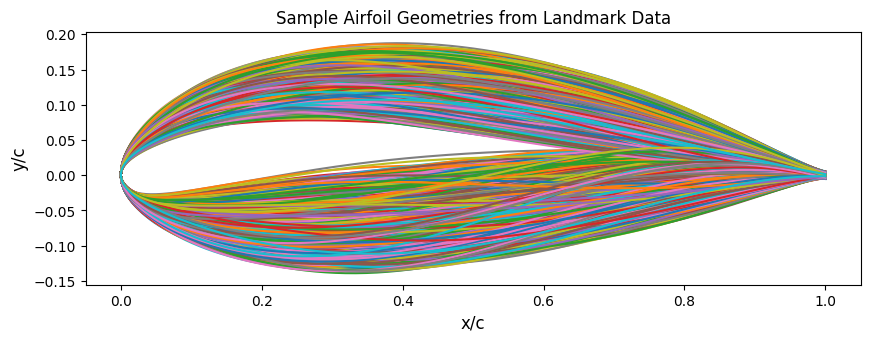

In [9]:
# clears current figure
# Visualize the first 5 airfoil geometries using the landmarks dataset
plt.figure(figsize=(10, 6))
with h5py.File(data_path_small, 'r') as hf:
    landmarks = hf['shape']['landmarks'][()]
    af_shape_count = 0
    for landmark in landmarks:
        plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
        af_shape_count += 1
plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()

Loading Functions from Utility

In [10]:
import importlib
import airfoil_utils
importlib.reload(airfoil_utils)
from airfoil_utils import (
    load_shape, load_aero_coeffs, load_flow_field,
    compute_thickness_camber, thickness_camber_dataframes,
    pca_reduce, pca_variance_curve,
    plot_airfoil_geometries, plot_pairwise_distributions,
    plot_aero_violins, plot_aero_vs_geometry, plot_flow_field, 
    plot_flow_field_plotly
)

Loading Data

In [11]:
# Load data
landmarks = load_shape(data_path_small, 'landmarks') # main parameter to use
# grassmann = load_shape(data_path_small, 'grassmann')
# cst       = load_shape(data_path_small, 'cst')
# bezier    = load_shape(data_path_small, 'bezier')

# Aerodynamic Coefficients
cl04, cd04, cm04 = load_aero_coeffs(data_path_small, 'alpha+04') # Angle of Attack 4 deg
cl12, cd12, cm12 = load_aero_coeffs(data_path_small, 'alpha+12') # Angle of Attack 12 deg

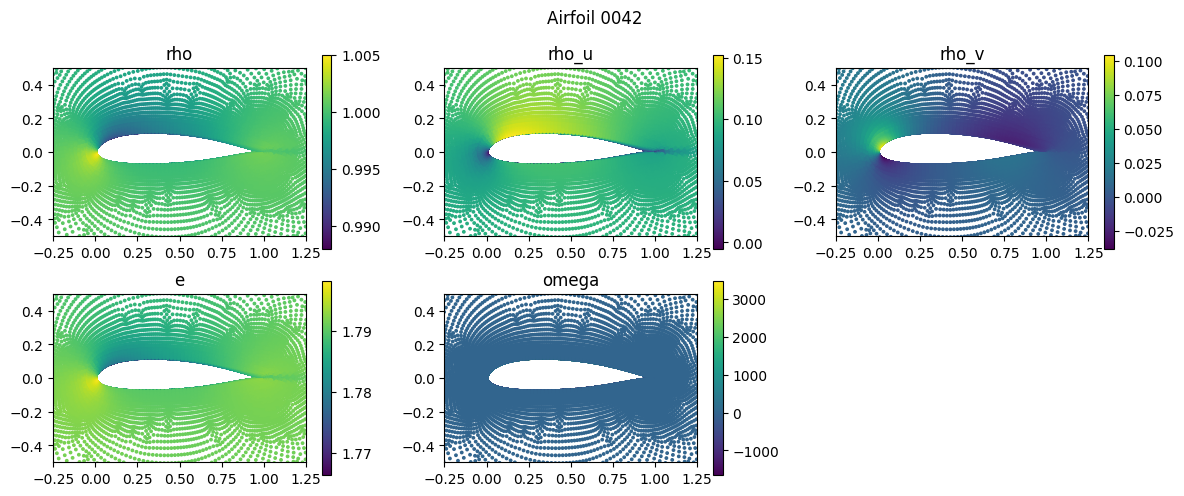

In [12]:
# Flow field
ff = load_flow_field(data_path_small, idx=42)
plot_flow_field(ff, idx=42)
# plot_flow_field_plotly(ff, idx=42, metric='rho')

Visualizing Flow Field of Two Angles of Attack of the same Airfoil  
NOTE: Consumes Large Memory

In [13]:
ff_04 = load_flow_field(data_path_small, idx=42, alpha='alpha+04')
ff_12 = load_flow_field(data_path_small, idx=42, alpha='alpha+12')

print("Angle of Attack 4 deg")
# plot_flow_field_plotly(ff_04, idx=42, metric='rho')
print("Angle of Attack 12 deg")
# plot_flow_field_plotly(ff_12, idx=42, metric='rho')


Angle of Attack 4 deg
Angle of Attack 12 deg


Markdown Image to Save Memory
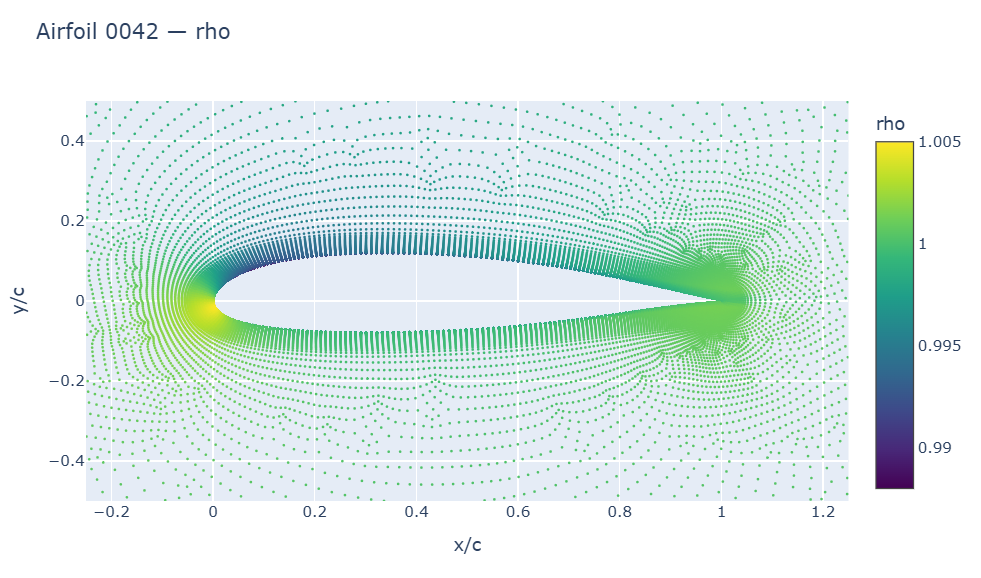

Loading Coefficent Results after Downsizing

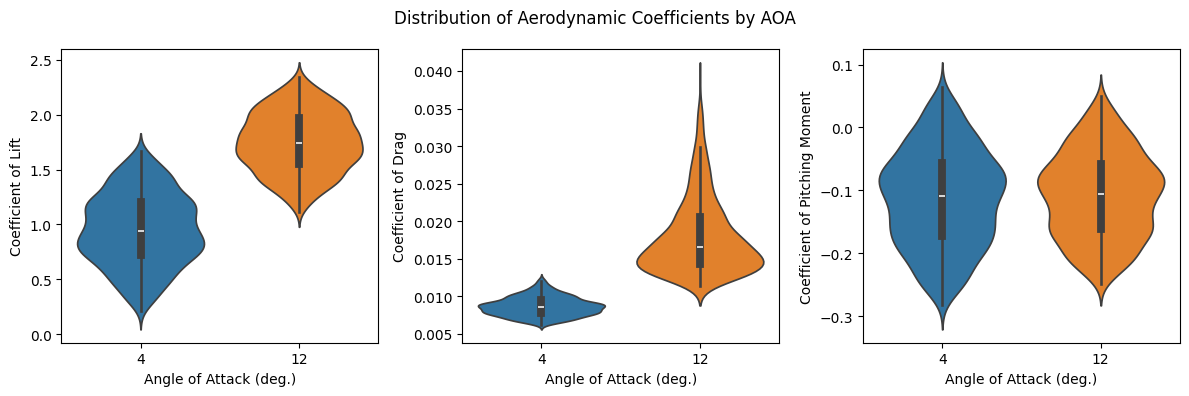

In [14]:
plot_aero_violins(cl04, cd04, cm04, cl12, cd12, cm12)

Rounding Coefficients to simplify prediction complexity

Unique values BEFORE rounding:
  cl04: 1000  |  cd04: 1000  |  cm04: 1000
  cl12: 1000  |  cd12: 999  |  cm12: 1000


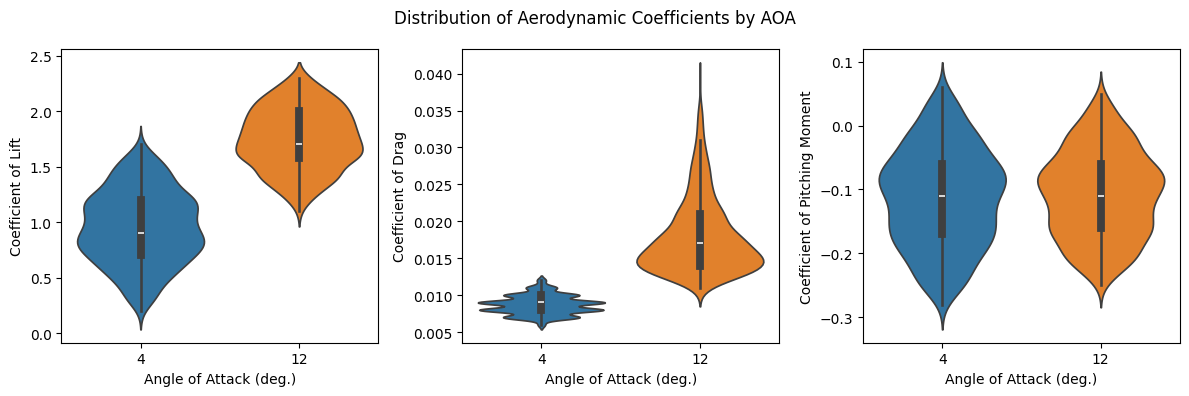

Unique values AFTER rounding:
  cl04: 16  |  cd04: 7  |  cm04: 35
  cl12: 13  |  cd12: 27  |  cm12: 31


In [15]:
# Before rounding
print("Unique values BEFORE rounding:")
print(f"  cl04: {len(np.unique(cl04))}  |  cd04: {len(np.unique(cd04))}  |  cm04: {len(np.unique(cm04))}")
print(f"  cl12: {len(np.unique(cl12))}  |  cd12: {len(np.unique(cd12))}  |  cm12: {len(np.unique(cm12))}")

plot_aero_violins(
    cl04.round(1), cd04.round(3), cm04.round(2),
    cl12.round(1), cd12.round(3), cm12.round(2)
)

cl04_round = cl04.round(1)
cd04_round = cd04.round(3)
cm04_round = cm04.round(2)
cl12_round = cl12.round(1)
cd12_round = cd12.round(3)
cm12_round = cm12.round(2)

# After rounding
print("Unique values AFTER rounding:")
print(f"  cl04: {len(np.unique(cl04_round))}  |  cd04: {len(np.unique(cd04_round))}  |  cm04: {len(np.unique(cm04_round))}")
print(f"  cl12: {len(np.unique(cl12_round))}  |  cd12: {len(np.unique(cd12_round))}  |  cm12: {len(np.unique(cm12_round))}")


### Data Processing Work

Converting Results into Grid Images  
Landmark data x,y are not the same for each airfoil and may hurt CNN learning. Adjusting them throug interpolation into fixed Grids should help fix the issue

In [16]:
importlib.reload(airfoil_utils)
from airfoil_utils import landmarks_to_grid, plot_airfoil_grid


In [17]:

# landmarks = load_shape(data_path_small, 'landmarks')
# # grids = landmarks_to_grid(landmarks, resolution=128)  # shape: (N, 128, 128)
# # save
# grids = landmarks_to_grid(landmarks, resolution=128, padding=0.2, save_path='data/airfoil_1k_grid_128.h5')

# # with h5py.File('data/grids_128.h5', 'r') as hf:
# #     alpha4_grids = hf['alpha4'][()]

In [18]:
# import math
# importlib.reload(airfoil_utils)
# # grids = landmarks_to_grid(landmarks)
# plot_airfoil_grid(grids, idx=0)


Saved Result  
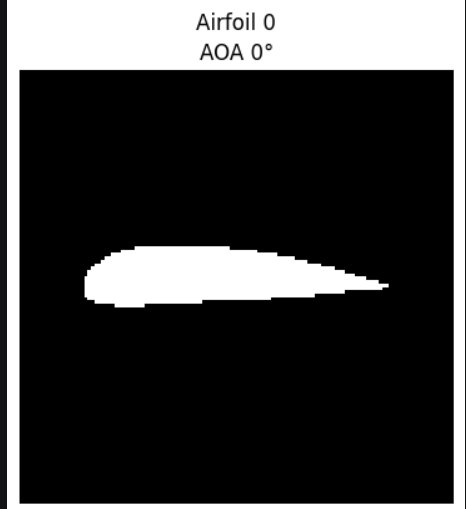

Angle Dimensions for 4deg angle of attack and 12deg angle of attack

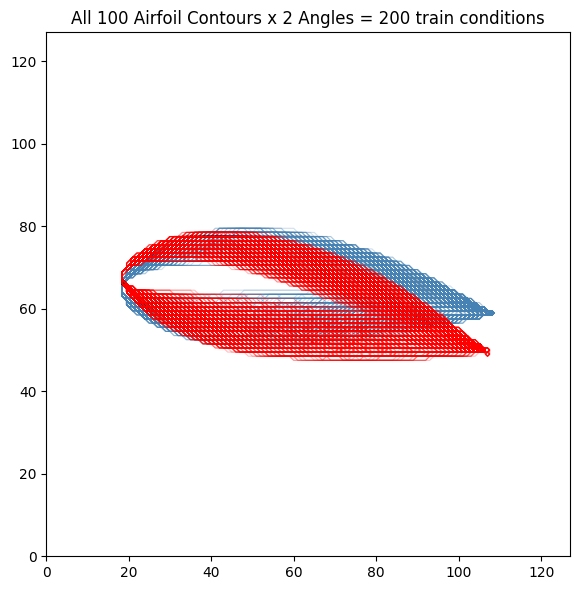

In [19]:
orientation = 'alpha4'  # choose: 'alpha0', 'alpha4', 'alpha12'
data_airfoil = 'data/airfoil_01k_grid_128.h5'
data_airfoil = 'data/airfoil_1k_grid_128.h5'


with h5py.File(data_airfoil, 'r') as hf:
    grids = hf[orientation][()]  # (100, 128, 128)

plt.figure(figsize=(10, 6))
for grid in grids:
    plt.contour(grid, levels=[0.5], colors=['steelblue'], alpha=0.25, linewidths=0.8)


orientation = 'alpha12'  # choose: 'alpha0', 'alpha4', 'alpha12'

with h5py.File(data_airfoil, 'r') as hf:
    grids = hf[orientation][()]  # (100, 128, 128)

for grid in grids:
    plt.contour(grid, levels=[0.5], colors=['red'], alpha=0.25, linewidths=0.8)

plt.gca().set_aspect(1.)
plt.title(f'All 100 Airfoil Contours x 2 Angles = 200 train conditions')
plt.tight_layout()
# plt.show()

Saved Result  
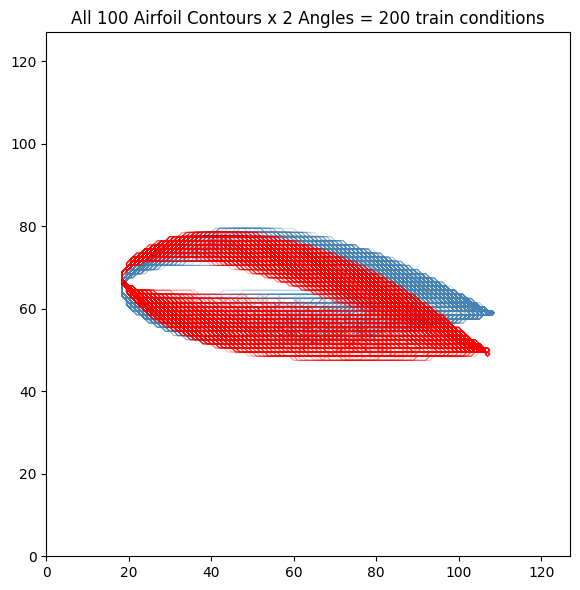

## CNN Modeling

Dataset Preparation: Combining and Assigning Aerodynamic Coefficient Values to their corresponding Airfoil designs

In [20]:
def build_dataset(h5_path, cl04, cd04, cm04, cl12, cd12, cm12):
    with h5py.File(h5_path, 'r') as hf:
        grids_04 = hf['alpha4'][()]   # (100, 128, 128)
        grids_12 = hf['alpha12'][()]  # (100, 128, 128)

    x_data = np.concatenate([grids_04, grids_12], axis=0)  # (200, 128, 128)

    y_04 = np.stack([cl04, cd04, cm04], axis=1)  # (100, 3)
    y_12 = np.stack([cl12, cd12, cm12], axis=1)  # (100, 3)
    y_data = np.concatenate([y_04, y_12], axis=0)  # (200, 3)

    return x_data, y_data


x_data, y_data = build_dataset(
    data_airfoil,
    cl04_round, cd04_round, cm04_round,
    cl12_round, cd12_round, cm12_round
)

print("x_data:", x_data.shape)  # (200, 128, 128)
print("y_data:", y_data.shape)  # (200, 3) — [cl, cd, cm]


x_data: (2000, 128, 128)
y_data: (2000, 3)


Dataset Preparation: Splitting Data to Get Train/Validation Data and Test Data

In [21]:
from sklearn.model_selection import train_test_split


# --- Step 1: Split into Train (70%) and Temp (30%) ---
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x_data, y_data,
    test_size=0.2,           # 30% for val+test
    random_state=42,         # reproducibility
    stratify=None            # set to y if classification
)

print(f"Train and Val size: {len(x_train_val)} rows ({len(x_train_val)/len(x_data)*100:.1f}%)")
print(f"Test size: {len(x_test)} rows ({len(x_test)/len(x_data)*100:.1f}%)")

Train and Val size: 1600 rows (80.0%)
Test size: 400 rows (20.0%)


Normalizing Coefficient Ouputs  
These will be used to normalize the 3 outputs and at the same time create the function normalize mean to be used in keras tuner.

In [22]:
# import keras_tuner as kt
import tensorflow as tf
# Per-coefficient scale = approximate range of each output in the training data
# Cl ~ [-0.5, 2.0] → range 2.5 | Cd ~ [0.005, 0.1] → range 0.095 | Cm ~ [-0.15, 0.05] → range 0.2
CL_SCALE = float(y_train_val[:, 0].max() - y_train_val[:, 0].min())
CD_SCALE = float(y_train_val[:, 1].max() - y_train_val[:, 1].min())
CM_SCALE = float(y_train_val[:, 2].max() - y_train_val[:, 2].min())
SCALES   = tf.constant([CL_SCALE, CD_SCALE, CM_SCALE], dtype=tf.float32)
print(f"Scales — Cl: {CL_SCALE:.4f}  Cd: {CD_SCALE:.4f}  Cm: {CM_SCALE:.4f}")

def normalized_mae(y_true, y_pred):
    """MAE normalized per coefficient so all three contribute equally."""
    return tf.reduce_mean(tf.abs(y_true - y_pred) / SCALES)

Scales — Cl: 2.1000  Cd: 0.0330  Cm: 0.3400


In [23]:
# --- Normalize targets (train/val and test) using training-data scales ---
# y_train_val, y_test are assumed shape: (n_samples, 3) with columns [cl, cd, cm]

# Avoid divide-by-zero in case any coefficient has zero range
eps = 1e-8
scales_np = np.array([CL_SCALE, CD_SCALE, CM_SCALE], dtype=np.float32)
scales_np = np.where(scales_np < eps, 1.0, scales_np)

y_train_val_norm = y_train_val.astype(np.float32) / scales_np
y_test_norm      = y_test.astype(np.float32) / scales_np

print("Normalized y shapes:")
print("y_train_val_norm:", y_train_val_norm.shape)
print("y_test_norm     :", y_test_norm.shape)

print("\nQuick check (min/max per column):")
print("train norm min:", y_train_val_norm.min(axis=0))
print("train norm max:", y_train_val_norm.max(axis=0))
print("test  norm min:", y_test_norm.min(axis=0))
print("test  norm max:", y_test_norm.max(axis=0))


Normalized y shapes:
y_train_val_norm: (1600, 3)
y_test_norm     : (400, 3)

Quick check (min/max per column):
train norm min: [ 0.0952381   0.18181819 -0.8235294 ]
train norm max: [1.0952381  1.1818182  0.17647058]
test  norm min: [ 0.14285715  0.18181819 -0.7941177 ]
test  norm max: [1.0952381  1.0606061  0.17647058]


### CNN Model Architecture: Manual Build

CNN Model Architecture Version 1
- Using CNN with layers.Dense(3) to predict all 3 outputs per airfoil input
- Architecture Follows the most standard version of CNN network used in Class
- This will be set as the baseline model for the CNN architecture to try and improve

In [24]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# --- Preprocess inputs: add channel dim, cast to float ---
x_train_val    = x_train_val.reshape(-1, 128, 128, 1).astype("float32")
x_test     = x_test.reshape(-1, 128, 128, 1).astype("float32")

# y_data is already float (cl, cd, cm) — no one-hot encoding needed

# --- CNN Regression Model (3 outputs: cl, cd, cm) ---
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3)  # regression: cl, cd, cm. activation="softmax" is only for classification
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    x_train_val, y_train_val,
    epochs=20,
    batch_size=16, #Common rule of thumb: 16,32, or 64 batch size should be roughly sqrt(sample size).
    # validation_data=(x_val, y_val)
    validation_split=0.1
)

model.save("models/airfoil_cnn.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,267 (12.46 MB)

 Trainable params: 3,267,267 (12.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0910 - mae: 0.2072 - val_loss: 0.0124 - val_mae: 0.0755
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0552 - mae: 0.1575 - val_loss: 0.0031 - val_mae: 0.0363
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0455 - mae: 0.1374 - val_loss: 0.0103 - val_mae: 0.0628
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0420 - mae: 0.1235 - val_loss: 0.0021 - val_mae: 0.0305
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0368 - mae: 0.1124 - val_loss: 0.0040 - val_mae: 0.0414
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0346 - mae: 0.1050 - val_loss: 0.0130 - val_mae: 0.0730
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0304 - mae: 0.0974 - val_loss: 0.0084 - val_mae: 0.0540
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0295 - mae: 0.0956 - val_loss: 0.0054 - val_mae: 0.0469
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.030

CNN Model Architecture Version 2  
- Based from Food101 Learnings we will apply VGG16 CNN architecture
- Based from Class we will apply augmentation ton randomize the results. Important note because we are dealing with airfoils. rotation will not be included as angle is a direct effect to the coefficient of lift output.
- **The VGG-16 Architecture** stacks many small 3x3 convolutions in a clean pattern, which learns rich hierarchical features while staying easy to understand and modify. It’s also a strong transfer-learning backbone with lots of pretrained weights and references.
    - The architecture is now commonly used as a benchmark and in many feature extraction tasks across computer vision projects

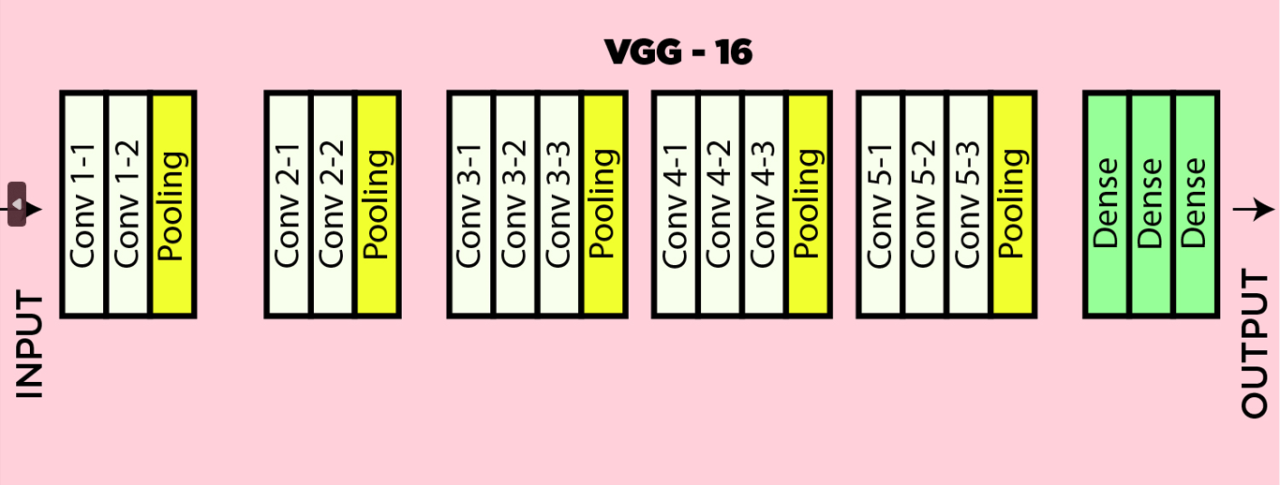

In [31]:
from tensorflow import keras
from tensorflow.keras import layers, models
import tensorflow as tf

# --- Preprocess inputs: add channel dim, cast to float ---
x_train_val = x_train_val.reshape(-1, 128, 128, 1).astype("float32")
x_test      = x_test.reshape(-1, 128, 128, 1).astype("float32")

data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomZoom(height_factor=0.20, width_factor=0.20),
    # layers.Resizing(224, 224),
], name="data_augmentation")

# VGG16-lite: same block pattern, fewer filters + smaller head
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Block 5
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Lite regression head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3)  # cl, cd, cm

    # layers.Input(shape=(128, 128, 1)),
    # layers.Conv2D(32, (3, 3), activation="relu"),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(64, (3, 3), activation="relu"),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(64, (3, 3), activation="relu"),
    # layers.Flatten(),
    # layers.Dense(64, activation="relu"),
    # layers.Dropout(0.5),
    # layers.Dense(3) 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse",
    metrics=["mae"]
)
# model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)
]

history = model.fit(
    x_train_val, y_train_val_norm,
    epochs=60,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks
)

model.save("models/airfoil_vgg16.keras")


Epoch 1/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - loss: 0.0819 - mae: 0.2253 - val_loss: 0.0419 - val_mae: 0.1663 - learning_rate: 1.0000e-04
Epoch 2/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0519 - mae: 0.1810 - val_loss: 0.0343 - val_mae: 0.1568 - learning_rate: 1.0000e-04
Epoch 3/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - loss: 0.0400 - mae: 0.1560 - val_loss: 0.0305 - val_mae: 0.1531 - learning_rate: 1.0000e-04
Epoch 4/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - loss: 0.0289 - mae: 0.1307 - val_loss: 0.0288 - val_mae: 0.1481 - learning_rate: 1.0000e-04
Epoch 5/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - loss: 0.0273 - mae: 0.1277 - val_loss: 0.0353 - val_mae: 0.1599 - learning_rate: 1.0000e-04
Epoch 6/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - loss: 0.0254 - mae: 0.1229 - val_loss: 0.0152 - val_mae: 0.0949 - learning_rate: 1.0000e-04
Epoch 7/60
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - loss: 0.0237 - mae: 0.1198 - val_loss: 0.0155 - val_mae: 0.0974

### Hyperparameter Tuning with Keras Tuner

Constructing the Target Metric to Optimize. Minimizing the average error of all 3 aerodynamic coefficients with minmax normalization.

In [ ]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import os


Scales — Cl: 2.1000  Cd: 0.0330  Cm: 0.3400


Run Keras Tuner  
NOTE: Long Run

In [ ]:
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(128, 128, 1)))

    model.add(layers.Conv2D(
        filters=hp.Choice("filters_1", [16, 32, 48]),
        kernel_size=hp.Choice("kernel_1", [3, 5]),
        activation="relu", padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(
        filters=hp.Choice("filters_2", [32, 64, 96]),
        kernel_size=hp.Choice("kernel_2", [3, 5]),
        activation="relu", padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    if hp.Boolean("use_block3"):
        model.add(layers.Conv2D(
            filters=hp.Choice("filters_3", [64, 96, 128]),
            kernel_size=3, activation="relu", padding="same"
        ))

    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Choice("dense_units", [64, 128, 256]), activation="relu"))
    model.add(layers.Dropout(hp.Float("dropout", 0.2, 0.6, step=0.1)))
    model.add(layers.Dense(3))

    opt_name = hp.Choice("optimizer", ["adam", "rmsprop"])
    lr       = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4, 1e-4])
    optimizer = (keras.optimizers.Adam(learning_rate=lr)
                 if opt_name == "adam"
                 else keras.optimizers.RMSprop(learning_rate=lr))

    model.compile(optimizer=optimizer, loss=normalized_mae, metrics=[normalized_mae])
    return model

tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_normalized_mae", direction="min"),
    max_epochs=12,
    factor=3,
    directory="kt_results",
    project_name="airfoil_cnn_normalized",
    overwrite=True
)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

tuner.search(
    x_train_val, y_train_val,
    validation_split=0.1,
    epochs=12,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(f"  {k}: {best_hp.get(k)}")

best_model = tuner.get_best_models(1)[0]
test_loss, test_nmae = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Best model — normalized MAE: {test_nmae:.4f}")
print("(≈1.0 means avg error is ~100% of each coeff's range — lower is better)")

os.makedirs("models", exist_ok=True)
best_model.save("models/airfoil_cnn_tuned.keras")
print("Saved: models/airfoil_cnn_tuned.keras")


Trial 30 Complete [00h 00m 38s]
val_normalized_mae: 0.04237382486462593

Best val_normalized_mae So Far: 0.030391797423362732
Total elapsed time: 00h 14m 44s
Best hyperparameters:
  filters_1: 16
  kernel_1: 5
  filters_2: 32
  kernel_2: 5
  use_block3: False
  dense_units: 256
  dropout: 0.30000000000000004
  optimizer: rmsprop
  learning_rate: 0.001
  tuner/epochs: 12
  tuner/initial_epoch: 4
  tuner/bracket: 2
  tuner/round: 2
  tuner/trial_id: 0012
  filters_3: 128
Best model — normalized MAE: 0.0312
(≈1.0 means avg error is ~100% of each coeff's range — lower is better)
Saved: models/airfoil_cnn_tuned.keras


### Model Evaluation of CNN


Evaluating **CNN Model Architecture Version 1** with the 1000 airfoil sample dataset  
Observation Notes:
Coefficient of Lift is rather simple to achieve high test accuracy with coefficient of drag and momentum being more difficult to predict.
This is not using Keras Tuner Yet

Test Loss: 0.0036
Test MAE:  0.0351

Per-output metrics:
  cl: MAE=0.0820  RMSE=0.1016  R²=0.9618
  cd: MAE=0.0046  RMSE=0.0059  R²=0.1220
  cm: MAE=0.0188  RMSE=0.0232  R²=0.8959


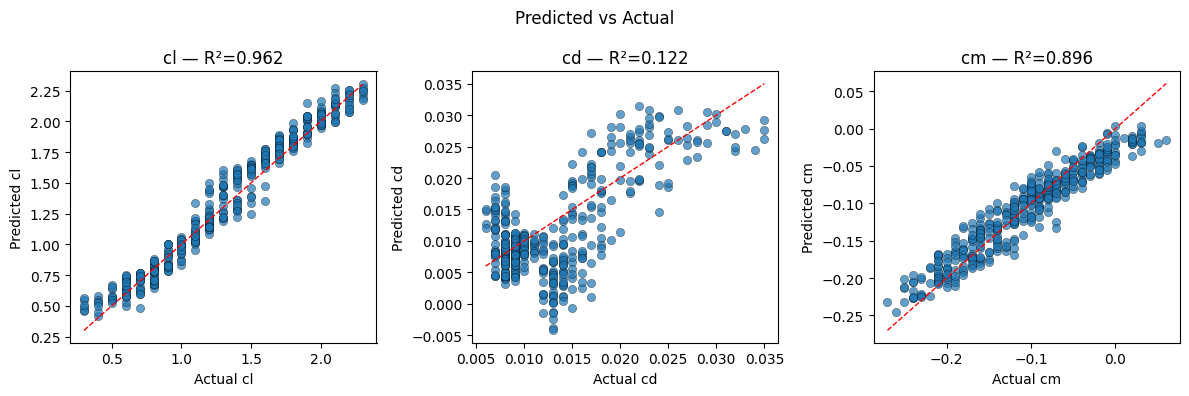

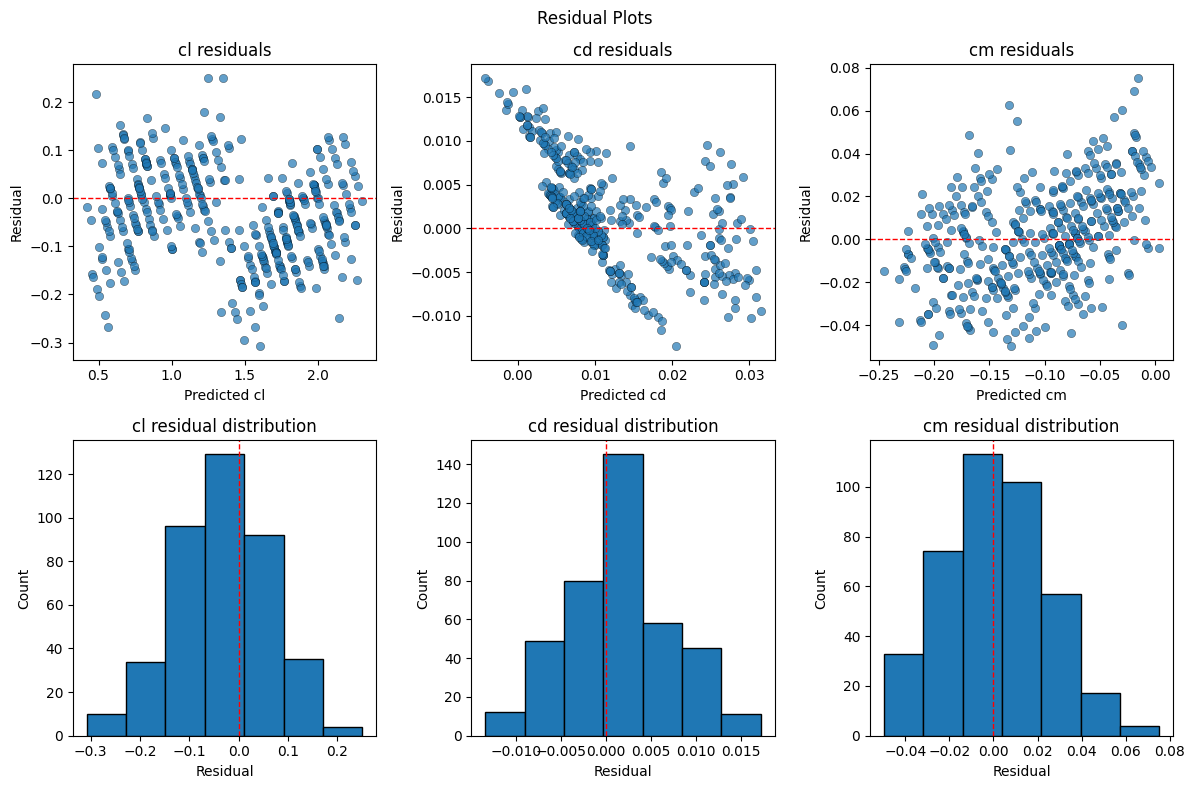

In [26]:
importlib.reload(airfoil_utils)
from airfoil_utils import evaluate_model

def normalized_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred) / SCALES)

model_base = keras.models.load_model("models/airfoil_cnn_baseline.keras")
# model_base = keras.models.load_model("models/airfoil_cnn_tuned_1k.keras")
evaluate_model(model_base, x_test, y_test)

Evaluating **CNN Model Architecture version 1 Modified with Keras Tuner**. The baseline architecture does not take into consideration the scale of values between the Coefficients Cl, Cd, and Cm (Note how Cd is much smaller). Thus normalized_mae(y_true, y_pred) was created to aim to target a CNN model that minimizes error for all 3 coefficients in their respective ranges.

Here we can now see how much the results have improved from the baseline method.

Test Loss: 0.0313
Test MAE:  0.0312

Per-output metrics:
  cl: MAE=0.0807  RMSE=0.1053  R²=0.9590
  cd: MAE=0.0010  RMSE=0.0014  R²=0.9508
  cm: MAE=0.0089  RMSE=0.0115  R²=0.9743


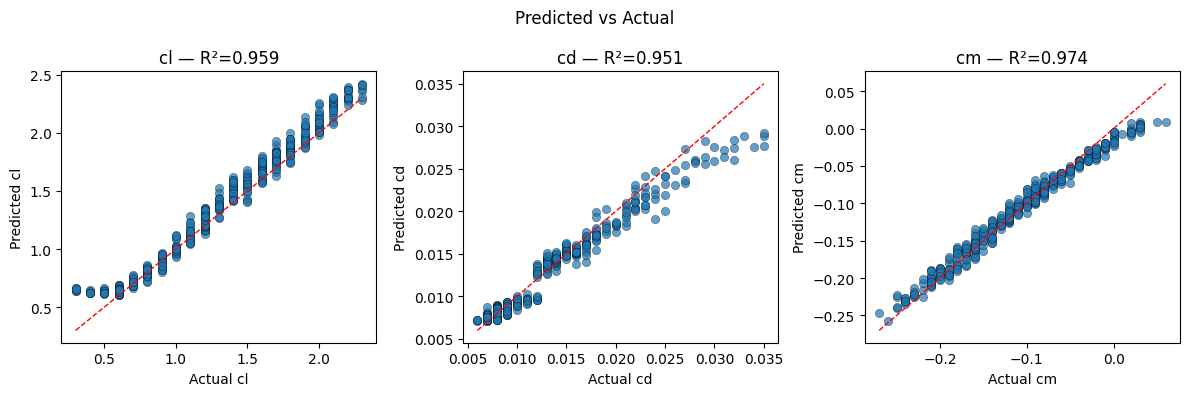

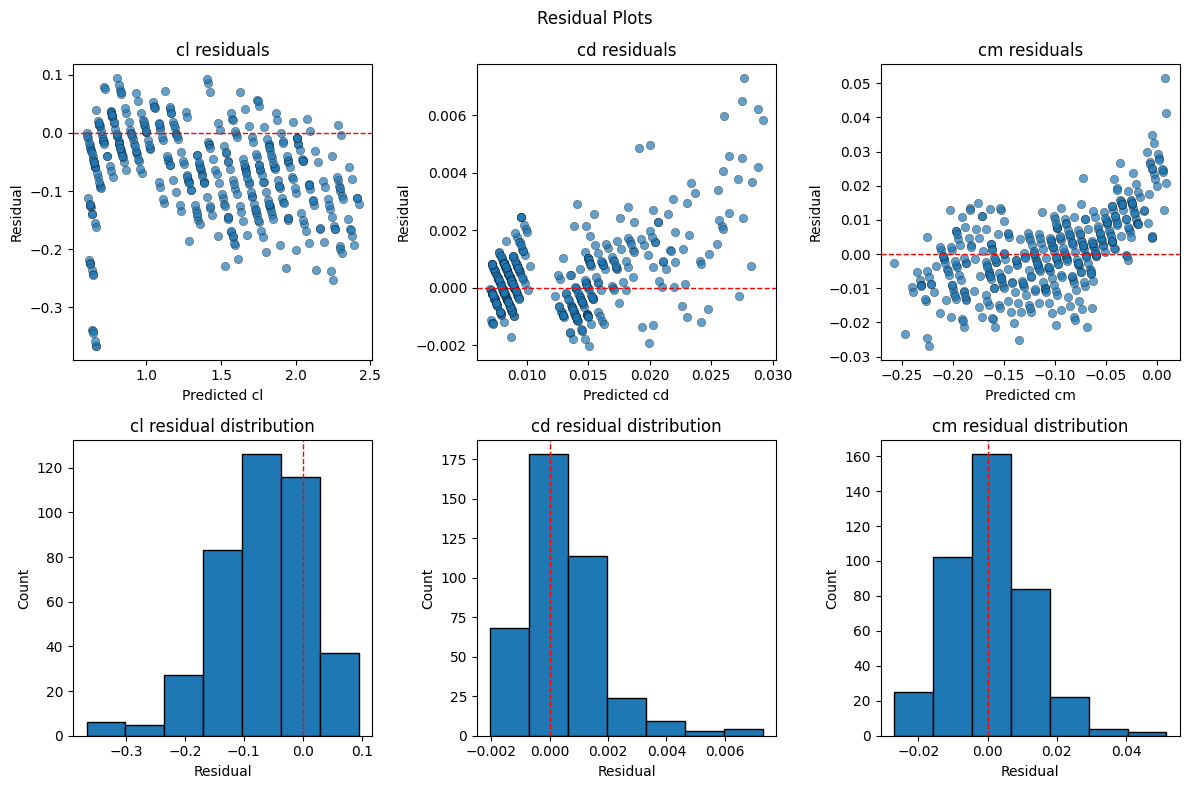

In [30]:
import importlib
importlib.reload(airfoil_utils)
from airfoil_utils import evaluate_model

def normalized_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred) / SCALES)

# pick one model path
MODEL_PATH = "models/airfoil_cnn_tuned_1k.keras"
# MODEL_PATH = "models/airfoil_cnn_baseline.keras"

model = keras.models.load_model(
    MODEL_PATH,
    custom_objects={"normalized_mae": normalized_mae},  # needed only if used in training
    compile=True
)

evaluate_model(model, x_test, y_test)


Evaluating **CNN Model Architecture version 2** this one incorporates VGG-16 Layer architecture and two random translation and zoom layer augmentation. The Model has given us the lowest Test Loss of all the models made so far at 0.0009.

Test Loss: 0.0009
Test MAE:  0.0222

Per-output metrics:
  cl: MAE=0.0218  RMSE=0.0278  R²=0.9873
  cd: MAE=0.0239  RMSE=0.0347  R²=0.9672
  cm: MAE=0.0208  RMSE=0.0267  R²=0.9841


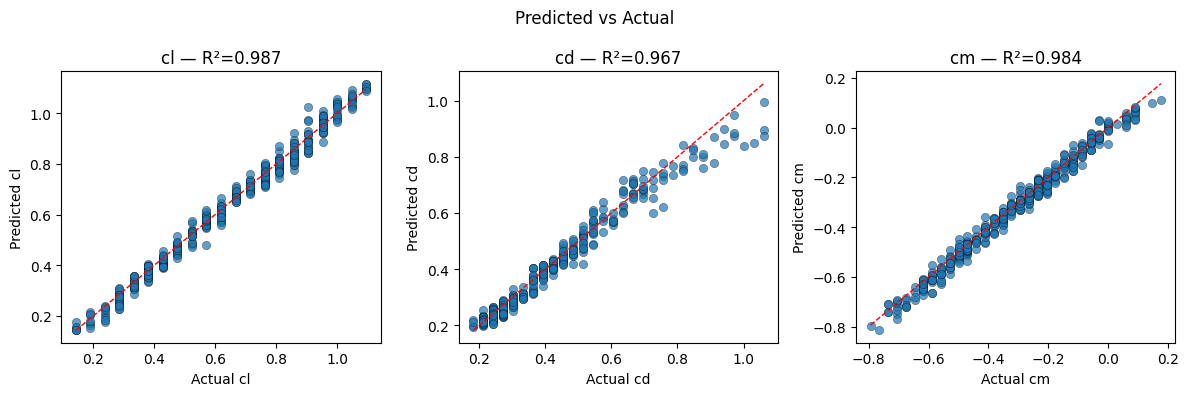

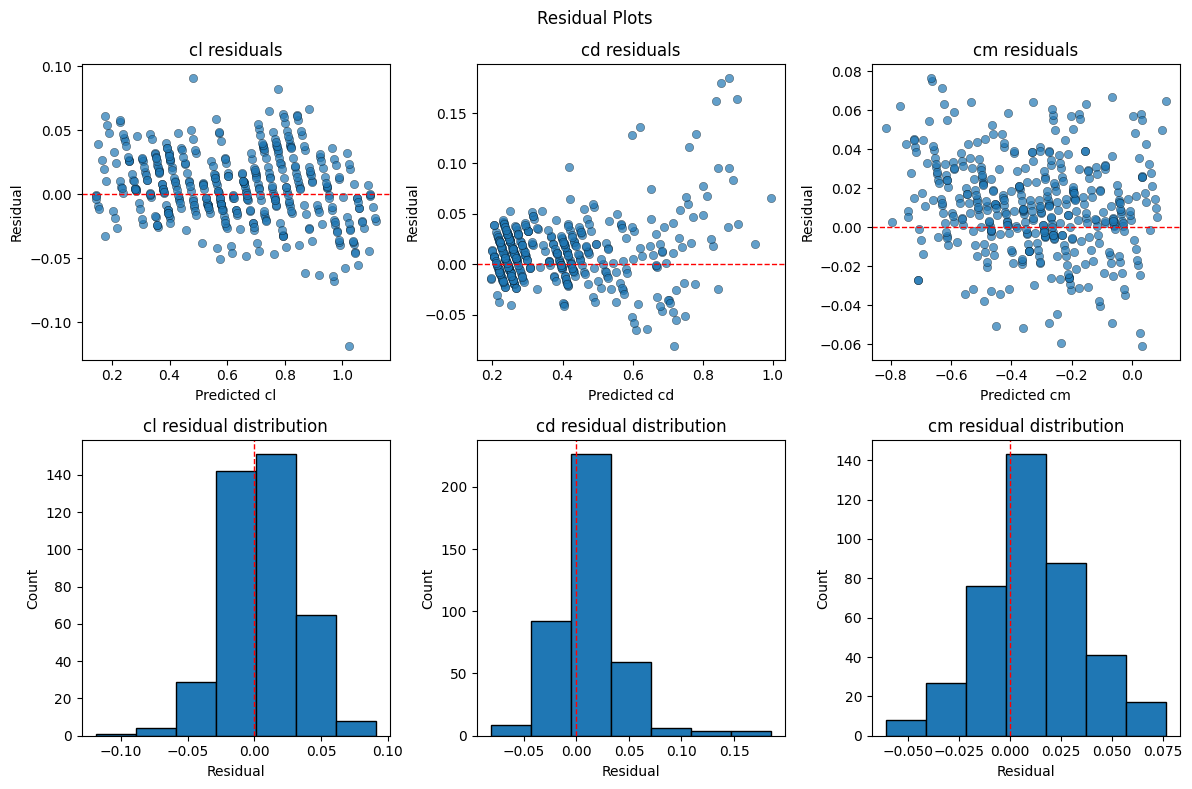

In [41]:
model_base = keras.models.load_model("models/airfoil_vgg16_best1_1k.keras")
# model_base = keras.models.load_model("models/airfoil_cnn_tuned_1k.keras")
evaluate_model(model_base, x_test, y_test_norm)

### Draw Airfoil Test

Load Model: For Outputs already normalized

In [43]:
import os
import numpy as np

# Same scales used during training normalization
eps = 1e-8
scales_np = np.array([CL_SCALE, CD_SCALE, CM_SCALE], dtype=np.float32)
scales_np = np.where(scales_np < eps, 1.0, scales_np)

def normalized_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred) / scales_np)

MODEL_PATH = "models/airfoil_vgg16_best1_1k.keras"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

model = keras.models.load_model(
    MODEL_PATH,
    custom_objects={"normalized_mae": normalized_mae},
    compile=False
)
print(f"Loaded model from: {MODEL_PATH}")


# # ---------- Helpers for switching back to original units ----------
# # Model outputs normalized [cl, cd, cm]; convert back to raw units for draw test.
# def denormalize_y(y_norm):
#     return y_norm * scales_np

# def normalize_y(y_raw):
#     return y_raw / scales_np


# # Example: draw-test prediction x_draw shape should be (1,128,128,1)
# # x_draw = ...
# y_pred_norm = model.predict(x_draw, verbose=0)      # normalized output
# y_pred_raw  = denormalize_y(y_pred_norm)            # back to real cl, cd, cm

# cl, cd, cm = y_pred_raw[0]
# print(f"Predicted (raw units) -> Cl: {cl:.4f}, Cd: {cd:.5f}, Cm: {cm:.4f}")


Loaded model from: models/airfoil_vgg16_best1_1k.keras


Draw on Canvas

In [ ]:
# If needed once:
# %pip install ipycanvas

import numpy as np
from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets
from ipycanvas import Canvas
from IPython.display import clear_output

CANVAS_W, CANVAS_H = 280, 280
MODEL_W,  MODEL_H  = 128, 128
N_MC = 50           # MC Dropout passes
LABELS = ['Cl', 'Cd', 'Cm']

# --- UI ---
canvas     = Canvas(width=CANVAS_W, height=CANVAS_H, sync_image_data=True)
output     = widgets.Output()
btn_predict = widgets.Button(description="Predict",  button_style="primary")
btn_clear   = widgets.Button(description="Clear")

drawing = {"active": False}

def reset_canvas():
    canvas.fill_style  = "black"
    canvas.fill_rect(0, 0, CANVAS_W, CANVAS_H)
    canvas.stroke_style = "white"
    canvas.line_width   = 6      # thinner than digit widget — airfoil is a fine curve
    canvas.line_cap     = "round"
    canvas.line_join    = "round"

reset_canvas()

def on_mouse_down(x, y):
    drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if not drawing["active"]:
        return
    canvas.line_to(x, y)
    canvas.stroke()

def on_mouse_up(x, y):
    drawing["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def on_clear(_):
    reset_canvas()
    with output:
        output.clear_output(wait=True)
        print("Canvas cleared.")

def _mc_predict(m, x, n=N_MC):
    """n forward passes with dropout active → mean and std per output."""
    runs = np.stack([m(x, training=True).numpy() for _ in range(n)], axis=0)  # (n, 1, 3)
    return runs.mean(axis=0)[0], runs.std(axis=0)[0]   # each shape (3,)

def on_predict(_):
    rgba = np.array(canvas.get_image_data(0, 0, CANVAS_W, CANVAS_H), dtype=np.uint8)
    gray = rgba[:, :, 0]
    img  = Image.fromarray(gray, mode="L").resize((MODEL_W, MODEL_H), Image.LANCZOS)
    x    = np.array(img).astype("float32") / 255.0
    x    = x[np.newaxis, :, :, np.newaxis]

    mean_norm, std_norm = _mc_predict(model, x)

    # convert normalized outputs back to raw [Cl, Cd, Cm]
    mean = mean_norm * scales_np
    std  = std_norm * scales_np

    conf = 100.0 * np.abs(mean_norm) / (np.abs(mean_norm) + std_norm + 1e-9)

    rows = ""
    for name, mu, sigma, c in zip(LABELS, mean, std, conf):
        bar_w = int(c * 1.5)
        bar_color = "#4caf50" if c >= 70 else "#ff9800" if c >= 40 else "#f44336"
        rows += f"""
        <tr style='border-bottom:1px solid #e0e0e0'>
          <td style='padding:6px 14px;font-weight:700;font-size:16px'>{name}</td>
          <td style='padding:6px 14px;text-align:right;font-size:15px'>{mu:+.4f}</td>
          <td style='padding:6px 14px;text-align:right;color:#888;font-size:13px'>±{sigma:.4f}</td>
          <td style='padding:6px 14px'>
            <div style='display:flex;align-items:center;gap:8px'>
              <div style='background:{bar_color};width:{bar_w}px;height:12px;border-radius:6px'></div>
              <span style='font-size:13px;color:{bar_color};font-weight:600'>{c:.1f}%</span>
            </div>
          </td>
        </tr>"""


    html = f"""
    <div style='font-family:sans-serif;margin-top:8px'>
      <div style='font-size:14px;font-weight:700;margin-bottom:4px'>Predicted Aerodynamic Coefficients</div>
      <table style='border-collapse:collapse;width:100%'>
        <tr style='border-bottom:2px solid #bbb;color:#555;font-size:12px'>
          <th style='padding:4px 14px;text-align:left'>Coeff</th>
          <th style='padding:4px 14px;text-align:right'>Value</th>
          <th style='padding:4px 14px;text-align:right'>±σ</th>
          <th style='padding:4px 14px;text-align:left'>Confidence</th>
        </tr>
        {rows}
      </table>
      <div style='font-size:11px;color:#aaa;margin-top:6px'>
        MC Dropout · {N_MC} passes · conf = |μ| / (|μ| + σ)
      </div>
    </div>"""

    with output:
        output.clear_output(wait=True)
        display(HTML(html))

btn_clear._click_handlers.callbacks.clear()
btn_predict._click_handlers.callbacks.clear()
btn_clear.on_click(on_clear)
btn_predict.on_click(on_predict)

clear_output(wait=True)   # ← wipes old display slots before re-rendering
display(widgets.HBox([btn_clear, btn_predict]))
display(canvas)
display(output)


Canvas(height=280, sync_image_data=True, width=280)

Output()

## Benchmark Thin Airfoil Theory

In [52]:
x_data[1]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

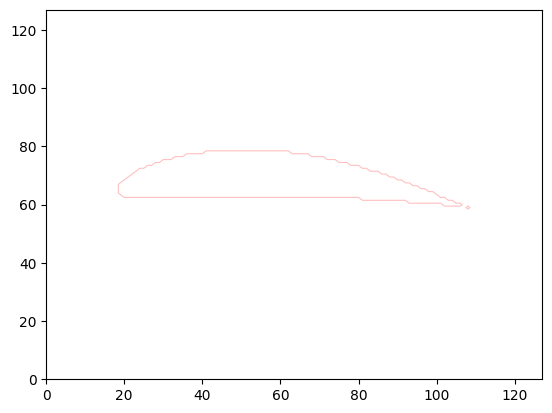

In [53]:
plt.contour(x_data[1], levels=[0.5], colors=['red'], alpha=0.25, linewidths=0.8)


In [54]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import simpson


def erau_modified_thin_airfoil(
    xy,
    alpha_deg,
    mach=0.1,
    reynolds=9_000_000,
    eta_a=0.95,
    cd0=None,
    use_prandtl_glauert=True,
    estimate_cd0_from_re=True,
    n_points=800,
):
    """
    ERAU-style Modified Thin Airfoil Theory baseline.

    Inputs
    ------
    xy : array-like, shape (N, 2)
        Airfoil coordinates [x, y]. Should trace the airfoil surface.
        Works best if coordinates are ordered around the airfoil.
    alpha_deg : float
        Angle of attack in degrees. Example: 4 or 12.
    mach : float
        Freestream Mach number. Thin airfoil theory is incompressible;
        optional Prandtl-Glauert correction is applied if use_prandtl_glauert=True.
    reynolds : float
        Reynolds number. ERAU does not give a Reynolds-based Cd0 formula,
        but this function can estimate a rough turbulent skin-friction Cd0.
    eta_a : float
        Leading-edge suction efficiency factor.
        ERAU notes eta_a < 1 for real flow. A value around 0.95 is a common
        low-to-moderate thickness assumption.
    cd0 : float or None
        Viscous / skin-friction drag offset.
        If None and estimate_cd0_from_re=True, a rough turbulent flat-plate
        estimate is used.
    use_prandtl_glauert : bool
        If True, applies low-subsonic compressibility correction:
        coefficient / sqrt(1 - M^2).
    estimate_cd0_from_re : bool
        If True and cd0 is None, estimates Cd0 from Reynolds number.
        This is an extra empirical approximation, not directly derived by ERAU.
    n_points : int
        Number of interpolation points along chord.

    Outputs
    -------
    dict containing:
        Cl
        Cd
        Cm_c4
        Cm_LE
        alpha_zero_lift_deg
        A0, A1, A2
        cd0_used
        eta_a
    """

    xy = np.asarray(xy, dtype=float)

    if xy.ndim != 2 or xy.shape[1] != 2:
        raise ValueError("xy must be an array of shape (N, 2).")

    if not (0 <= mach < 1):
        raise ValueError("mach should be subsonic for this model, e.g. 0.1.")

    alpha = np.deg2rad(alpha_deg)

    # ------------------------------------------------------------------
    # 1. Split airfoil into upper and lower surfaces
    # ------------------------------------------------------------------
    x_raw = xy[:, 0]
    le_idx = np.argmin(x_raw)

    surface_1 = xy[: le_idx + 1]
    surface_2 = xy[le_idx:]

    surface_1 = surface_1[np.argsort(surface_1[:, 0])]
    surface_2 = surface_2[np.argsort(surface_2[:, 0])]

    # Decide upper/lower by mean y-value
    if np.mean(surface_1[:, 1]) >= np.mean(surface_2[:, 1]):
        upper = surface_1
        lower = surface_2
    else:
        upper = surface_2
        lower = surface_1

    # Remove duplicate x-values to avoid interpolation errors
    def unique_x(surface):
        x = surface[:, 0]
        y = surface[:, 1]
        unique_vals = {}
        for xi, yi in zip(x, y):
            unique_vals.setdefault(xi, []).append(yi)
        xu = np.array(sorted(unique_vals.keys()))
        yu = np.array([np.mean(unique_vals[xi]) for xi in xu])
        return xu, yu

    xu, yu_raw = unique_x(upper)
    xl, yl_raw = unique_x(lower)

    x_min = max(xu.min(), xl.min())
    x_max = min(xu.max(), xl.max())
    chord = x_max - x_min

    if chord <= 0:
        raise ValueError("Invalid airfoil coordinates: chord length is zero or negative.")

    x = np.linspace(x_min, x_max, n_points)

    yu = interp1d(xu, yu_raw, kind="linear", fill_value="extrapolate")(x)
    yl = interp1d(xl, yl_raw, kind="linear", fill_value="extrapolate")(x)

    # Camberline
    yc = 0.5 * (yu + yl)

    # Normalize x and y by chord
    x_bar = (x - x_min) / chord
    yc_bar = yc / chord

    # Camberline slope dy_c/dx_bar
    dyc_dx = np.gradient(yc_bar, x_bar)

    # ------------------------------------------------------------------
    # 2. Glauert transform: x/c = (1 - cos(theta)) / 2
    # ------------------------------------------------------------------
    theta = np.linspace(1e-6, np.pi - 1e-6, n_points)
    x_theta = 0.5 * (1.0 - np.cos(theta))

    dyc_dx_theta = interp1d(
        x_bar,
        dyc_dx,
        kind="linear",
        fill_value="extrapolate"
    )(x_theta)

    # ------------------------------------------------------------------
    # 3. Thin airfoil Fourier coefficients
    # ------------------------------------------------------------------
    I0 = (1.0 / np.pi) * simpson(dyc_dx_theta, x=theta)

    A0 = alpha - I0
    A1 = (2.0 / np.pi) * simpson(dyc_dx_theta * np.cos(theta), x=theta)
    A2 = (2.0 / np.pi) * simpson(dyc_dx_theta * np.cos(2.0 * theta), x=theta)

    # ------------------------------------------------------------------
    # 4. Lift coefficient
    # ------------------------------------------------------------------
    Cl = 2.0 * np.pi * (A0 + 0.5 * A1)

    # ------------------------------------------------------------------
    # 5. Moment coefficients
    # ERAU:
    # Cm_LE = -pi * (A0 + A1 - A2/2)
    # Cm_c4 = Cm_LE + Cl/4
    #
    # Note:
    # Some thin-airfoil textbooks also report Cm_c4 = pi/4*(A2 - A1).
    # Here we follow the ERAU page relation explicitly.
    # ------------------------------------------------------------------
    Cm_LE = -np.pi * (A0 + A1 - 0.5 * A2)
    Cm_c4 = Cm_LE + 0.25 * Cl

    # ------------------------------------------------------------------
    # 6. Zero-lift angle
    # Cl = 2*pi[(alpha - I0) + A1/2]
    # Set Cl = 0:
    # alpha_0 = I0 - A1/2
    # ------------------------------------------------------------------
    alpha_zero_lift = I0 - 0.5 * A1

    # ------------------------------------------------------------------
    # 7. ERAU-style pressure drag correction
    #
    # Symmetric version:
    # Cd_pressure ≈ 2*pi*(1 - eta_a)*alpha^2
    #
    # Cambered version from ERAU form:
    # Cd_pressure ≈
    # 2*pi*alpha_0^2
    # - 4*pi*alpha_0*alpha
    # + 2*pi*(1 - eta_a)*alpha^2
    # ------------------------------------------------------------------
    Cd_pressure = (
        2.0 * np.pi * alpha_zero_lift**2
        - 4.0 * np.pi * alpha_zero_lift * alpha
        + 2.0 * np.pi * (1.0 - eta_a) * alpha**2
    )

    # ------------------------------------------------------------------
    # 8. Viscous drag offset Cd0
    #
    # ERAU adds Cd0 but does not give a Reynolds correlation.
    # If cd0 is not supplied, this uses a rough turbulent flat-plate estimate.
    # ------------------------------------------------------------------
    if cd0 is None:
        if estimate_cd0_from_re:
            # Rough turbulent flat-plate skin-friction estimate.
            # This is an empirical add-on, not pure thin airfoil theory.
            Cf = 0.074 / (reynolds ** 0.2)

            # Estimate wetted length ratio from airfoil surfaces
            def arc_length(surface):
                return np.sum(
                    np.sqrt(np.diff(surface[:, 0])**2 + np.diff(surface[:, 1])**2)
                )

            wetted_ratio = (arc_length(upper) + arc_length(lower)) / chord
            cd0_used = Cf * wetted_ratio
        else:
            cd0_used = 0.0
    else:
        cd0_used = float(cd0)

    Cd = cd0_used + Cd_pressure

    # Avoid negative drag from camber approximation artifacts
    Cd = max(Cd, 0.0)

    # ------------------------------------------------------------------
    # 9. Optional Prandtl-Glauert correction for Mach 0.1
    # Very small effect at M = 0.1.
    # ------------------------------------------------------------------
    if use_prandtl_glauert:
        beta = np.sqrt(1.0 - mach**2)
        Cl /= beta
        Cm_LE /= beta
        Cm_c4 /= beta
        # Usually do not apply this simple correction to empirical Cd0.
        # Leaving Cd unchanged keeps the drag estimate conservative/simple.

    return {
        "Cl": Cl,
        "Cd": Cd,
        "Cm_c4": Cm_c4,
        "Cm_LE": Cm_LE,
        "alpha_zero_lift_deg": np.rad2deg(alpha_zero_lift),
        "A0": A0,
        "A1": A1,
        "A2": A2,
        "cd0_used": cd0_used,
        "Cd_pressure_component": Cd_pressure,
        "eta_a": eta_a,
        "mach": mach,
        "reynolds": reynolds,
        "alpha_deg": alpha_deg,
        "notes": (
            "Modified thin airfoil theory baseline. Cl and Cm are analytical. "
            "Cd is semi-empirical. Not CFD; does not model stall, separation, "
            "thickness effects accurately, turbulence, or transition."
        ),
    }

In [72]:
import numpy as np
from skimage import measure

def raster_to_xy(mask_2d, level=0.5, min_points=80):
    """
    Convert a binary raster airfoil image (H,W) to an ordered (N,2) xy contour list.
    Returns xy in normalized coordinates:
      x in [0,1], y in [-0.5,0.5] (origin centered vertically)
    """
    # ensure binary float image
    img = (mask_2d > 0).astype(np.float32)

    # find all contours at boundary between 0 and 1
    contours = measure.find_contours(img, level=level)
    if not contours:
        raise ValueError("No contour found in raster image.")

    # choose the longest contour
    c = max(contours, key=len)  # shape: (N,2) in (row, col)
    if len(c) < min_points:
        raise ValueError(f"Contour too short: {len(c)} points")

    rows, cols = c[:, 0], c[:, 1]
    H, W = img.shape

    # pixel -> normalized coords
    x = cols / (W - 1)                  # [0,1]
    y = 0.5 - (rows / (H - 1))          # [-0.5,0.5], positive up

    xy = np.column_stack([x, y]).astype(np.float64)

    # rotate so first point is near trailing edge (max x), helps consistency
    i0 = np.argmax(xy[:, 0])
    xy = np.roll(xy, -i0, axis=0)

    return xy

# Example usage with your raster:
# x_data[i] is (128,128) image
i = 5
xy = raster_to_xy(x_data[i])

print("xy shape:", xy.shape)
print("first 5 points:\n", xy[:5])

# Then use:
result_4deg = erau_modified_thin_airfoil(xy, alpha_deg=4, mach=0.1, reynolds=9_000_000)
result_12deg = erau_modified_thin_airfoil(xy, alpha_deg=12, mach=0.1, reynolds=9_000_000)

print("\nRecorded Results from Modified Thin Airfoil Theory")
print("4 deg:", result_4deg)
print("12 deg:", result_12deg)
print("\nRecorded Results from Dataset")
print("4deg Aerodynamic Coefficients: ",cl04_round[i], cd04_round[i], cm04_round[i])
print("12deg Aerodynamic Coefficients:",cl12_round[i], cd12_round[i], cm12_round[i])


xy shape: (203, 2)
first 5 points:
 [[ 0.76771654  0.00393701]
 [ 0.76377953  0.        ]
 [ 0.75590551  0.        ]
 [ 0.7480315   0.        ]
 [ 0.74409449 -0.00393701]]

Recorded Results from Modified Thin Airfoil Theory
4 deg: {'Cl': np.float64(-0.01622530831514855), 'Cd': 0.0, 'Cm_c4': np.float64(0.155799903314952), 'Cm_LE': np.float64(0.15985623039373914), 'alpha_zero_lift_deg': np.float64(4.147215425792297), 'A0': np.float64(-0.05689828177574276), 'A1': np.float64(0.1086577757718836), 'A2': np.float64(0.2047765083160863), 'cd0_used': np.float64(0.006817032347221483), 'Cd_pressure_component': np.float64(-0.029050828745717242), 'eta_a': 0.95, 'mach': 0.1, 'reynolds': 9000000, 'alpha_deg': 4, 'notes': 'Modified thin airfoil theory baseline. Cl and Cm are analytical. Cd is semi-empirical. Not CFD; does not model stall, separation, thickness effects accurately, turbulence, or transition.'}
12 deg: {'Cl': np.float64(0.8654925267731672), 'Cd': 0.0, 'Cm_c4': np.float64(-0.06462955545712

In [64]:
cl04_round

array([1. , 1.5, 0.9, 1.2, 1.3, 1.3, 0.4, 0.6, 0.7, 0.8, 1.4, 0.6, 0.6,
       1. , 1.1, 1.5, 1.1, 0.9, 1.4, 0.4, 1.1, 1. , 1.6, 1. , 0.7, 1.2,
       1.4, 0.8, 1.5, 1.2, 1.2, 1. , 1. , 1.1, 0.8, 0.7, 0.5, 1.1, 0.7,
       1.5, 0.5, 1.4, 0.8, 0.5, 1.1, 0.3, 1.3, 0.6, 0.3, 0.5, 0.8, 0.8,
       0.7, 1.1, 1.5, 1.5, 0.9, 1. , 1.4, 0.8, 1.2, 0.5, 0.8, 1.6, 1.2,
       0.8, 1.2, 0.3, 1. , 0.8, 1.2, 0.3, 0.8, 0.8, 0.8, 1.1, 0.8, 0.7,
       0.8, 1.2, 1.1, 0.4, 0.7, 0.4, 0.5, 0.5, 0.7, 1.5, 1. , 1.7, 0.5,
       0.8, 0.9, 0.9, 1.1, 0.7, 1.4, 1.1, 1. , 1.4, 1.2, 0.5, 0.9, 1.1,
       1.4, 0.8, 1.1, 0.3, 1.1, 1.2, 1.5, 0.9, 0.9, 1.3, 0.7, 0.7, 0.3,
       0.7, 1.5, 0.9, 0.7, 0.3, 0.3, 0.4, 0.4, 0.9, 1.1, 1.4, 0.6, 0.7,
       0.8, 0.5, 0.6, 1. , 0.6, 0.6, 1.2, 1.3, 0.8, 1.4, 0.9, 0.9, 1.2,
       1.3, 0.9, 1.2, 1.3, 1.6, 1. , 1.2, 0.4, 1. , 0.9, 1. , 1.1, 0.8,
       0.5, 0.9, 0.6, 0.6, 0.7, 1.1, 0.7, 0.9, 1. , 0.3, 1. , 1.1, 0.3,
       0.6, 0.9, 0.9, 1.5, 0.9, 1.4, 0.8, 1.3, 1.1, 1.1, 0.9, 1.

## Modelling Flow Fields of Airfoils with Modified U-Net Neural Network

For this study we will push Convolutional Neural Networks to the test by predicting the flow fields using U-Net Neural Networks. This based on the following study:  
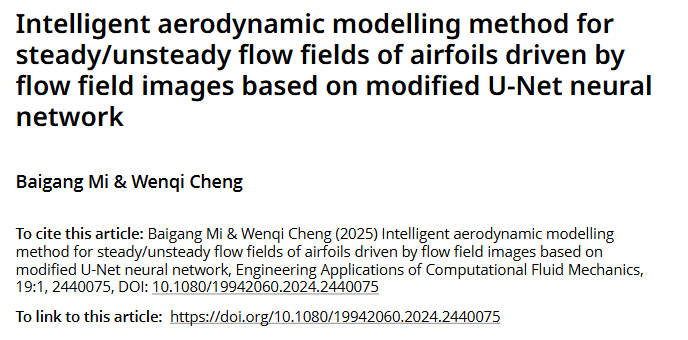

# Working with 9k Dataset Information

## Explore Airfoil Shapes & Parameterizations

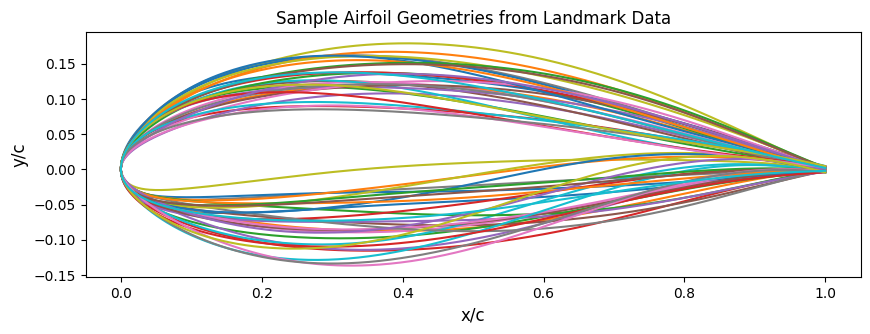

In [ ]:
# clears current figure
# Visualize the first 5 airfoil geometries using the landmarks dataset
plt.figure(figsize=(10, 6))
with h5py.File(data_path, 'r') as hf:
    landmarks = hf['shape']['landmarks'][()]
    af_shape_count = 0
    for landmark in landmarks[0:30]:
        plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
        af_shape_count += 1
plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()


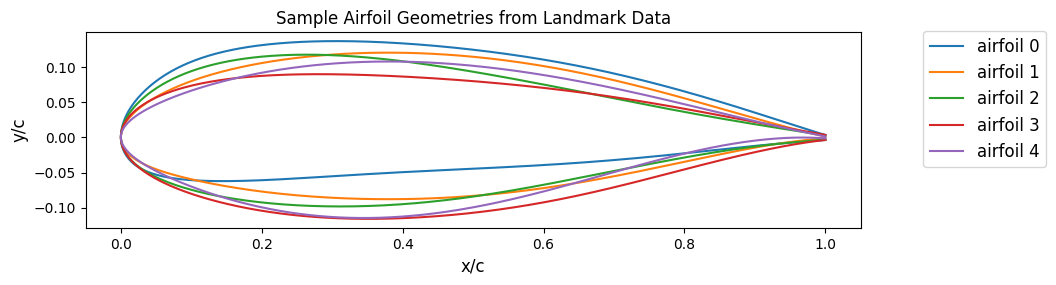

In [ ]:
# plt.close('all')
# # clears current figure
# # Visualize the first 5 airfoil geometries using the landmarks dataset
# plt.figure(figsize=(10, 6))
# with h5py.File(data_path, 'r') as hf:
#     landmarks = hf['shape']['landmarks'][()]
#     af_shape_count = 0
#     for landmark in landmarks[0:20]:
#         plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
#         af_shape_count += 1
# plt.xlabel('x/c', fontsize=12)
# plt.ylabel('y/c', fontsize=12)
# plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
# plt.title('Sample Airfoil Geometries from Landmark Data')
# plt.show()

import dask.array as da

plt.close('all')
plt.figure(figsize=(10, 6))

with h5py.File(data_path, 'r') as hf:
    landmarks = da.from_array(hf['shape']['landmarks'], chunks=500)
    landmarks_subset = landmarks[0:5].compute()  # only loads 20 rows

for i, landmark in enumerate(landmarks_subset):
    plt.plot(landmark[:, 0], landmark[:, 1], label=f'airfoil {i}')

plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()


In [ ]:
# # Capture reduced dimensionality parameterizations as objects and print shapes
# with h5py.File(data_path, 'r') as hf:
#     grassmann = hf['shape']['grassmann'][()]
#     print('Grassmann')
#     print(grassmann.shape)
    
#     cst = hf['shape']['cst'][()]
#     print('CST')
#     print(cst.shape)
    
#     bezier = hf['shape']['bezier'][()]
#     print('Bezier')
#     print(bezier.shape)

with h5py.File(data_path, 'r') as hf:
    grassmann = da.from_array(hf['shape']['grassmann'], chunks=500)
    print('Grassmann', grassmann.shape)

    cst = da.from_array(hf['shape']['cst'], chunks=500)
    print('CST', cst.shape)

    bezier = da.from_array(hf['shape']['bezier'], chunks=500)
    print('Bezier', bezier.shape)


Grassmann (8996, 4)
CST (8996, 19)
Bezier (8996, 15)


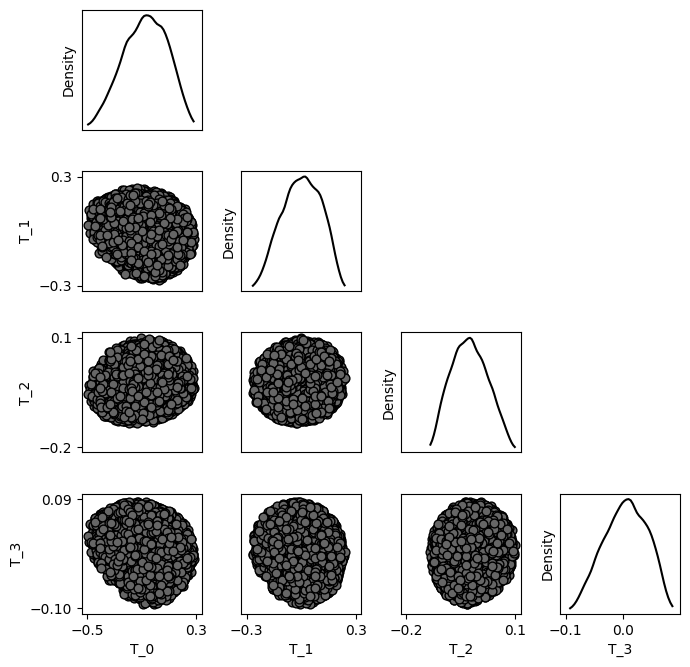

In [ ]:
with h5py.File(data_path, 'r') as hf:
    grassmann = da.from_array(hf['shape']['grassmann'], chunks=500).compute()

## Visualize distributions of Grassmann parameters
m = grassmann.shape[1]
grassmann_limits = []
for i in range(m):
    lower = grassmann[:,i].min()
    upper = grassmann[:,i].max()
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    grassmann_limits.append([lower,upper])

grassmann_labels = ['T_{}'.format(i) for i in range(m)]

plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(grassmann[:,i].min(), grassmann[:,i].max())
            kde = gaussian_kde(grassmann[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]),
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])
        else:
            plt.scatter(grassmann[:,j], grassmann[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(grassmann_limits[j])
            plt.yticks(grassmann_limits[i])
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(grassmann_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(grassmann_limits[j][0]-0.05*np.ptp(grassmann_limits[j]),
                     grassmann_limits[j][-1]+0.05*np.ptp(grassmann_limits[j]))
            plt.ylim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]),
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))
        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


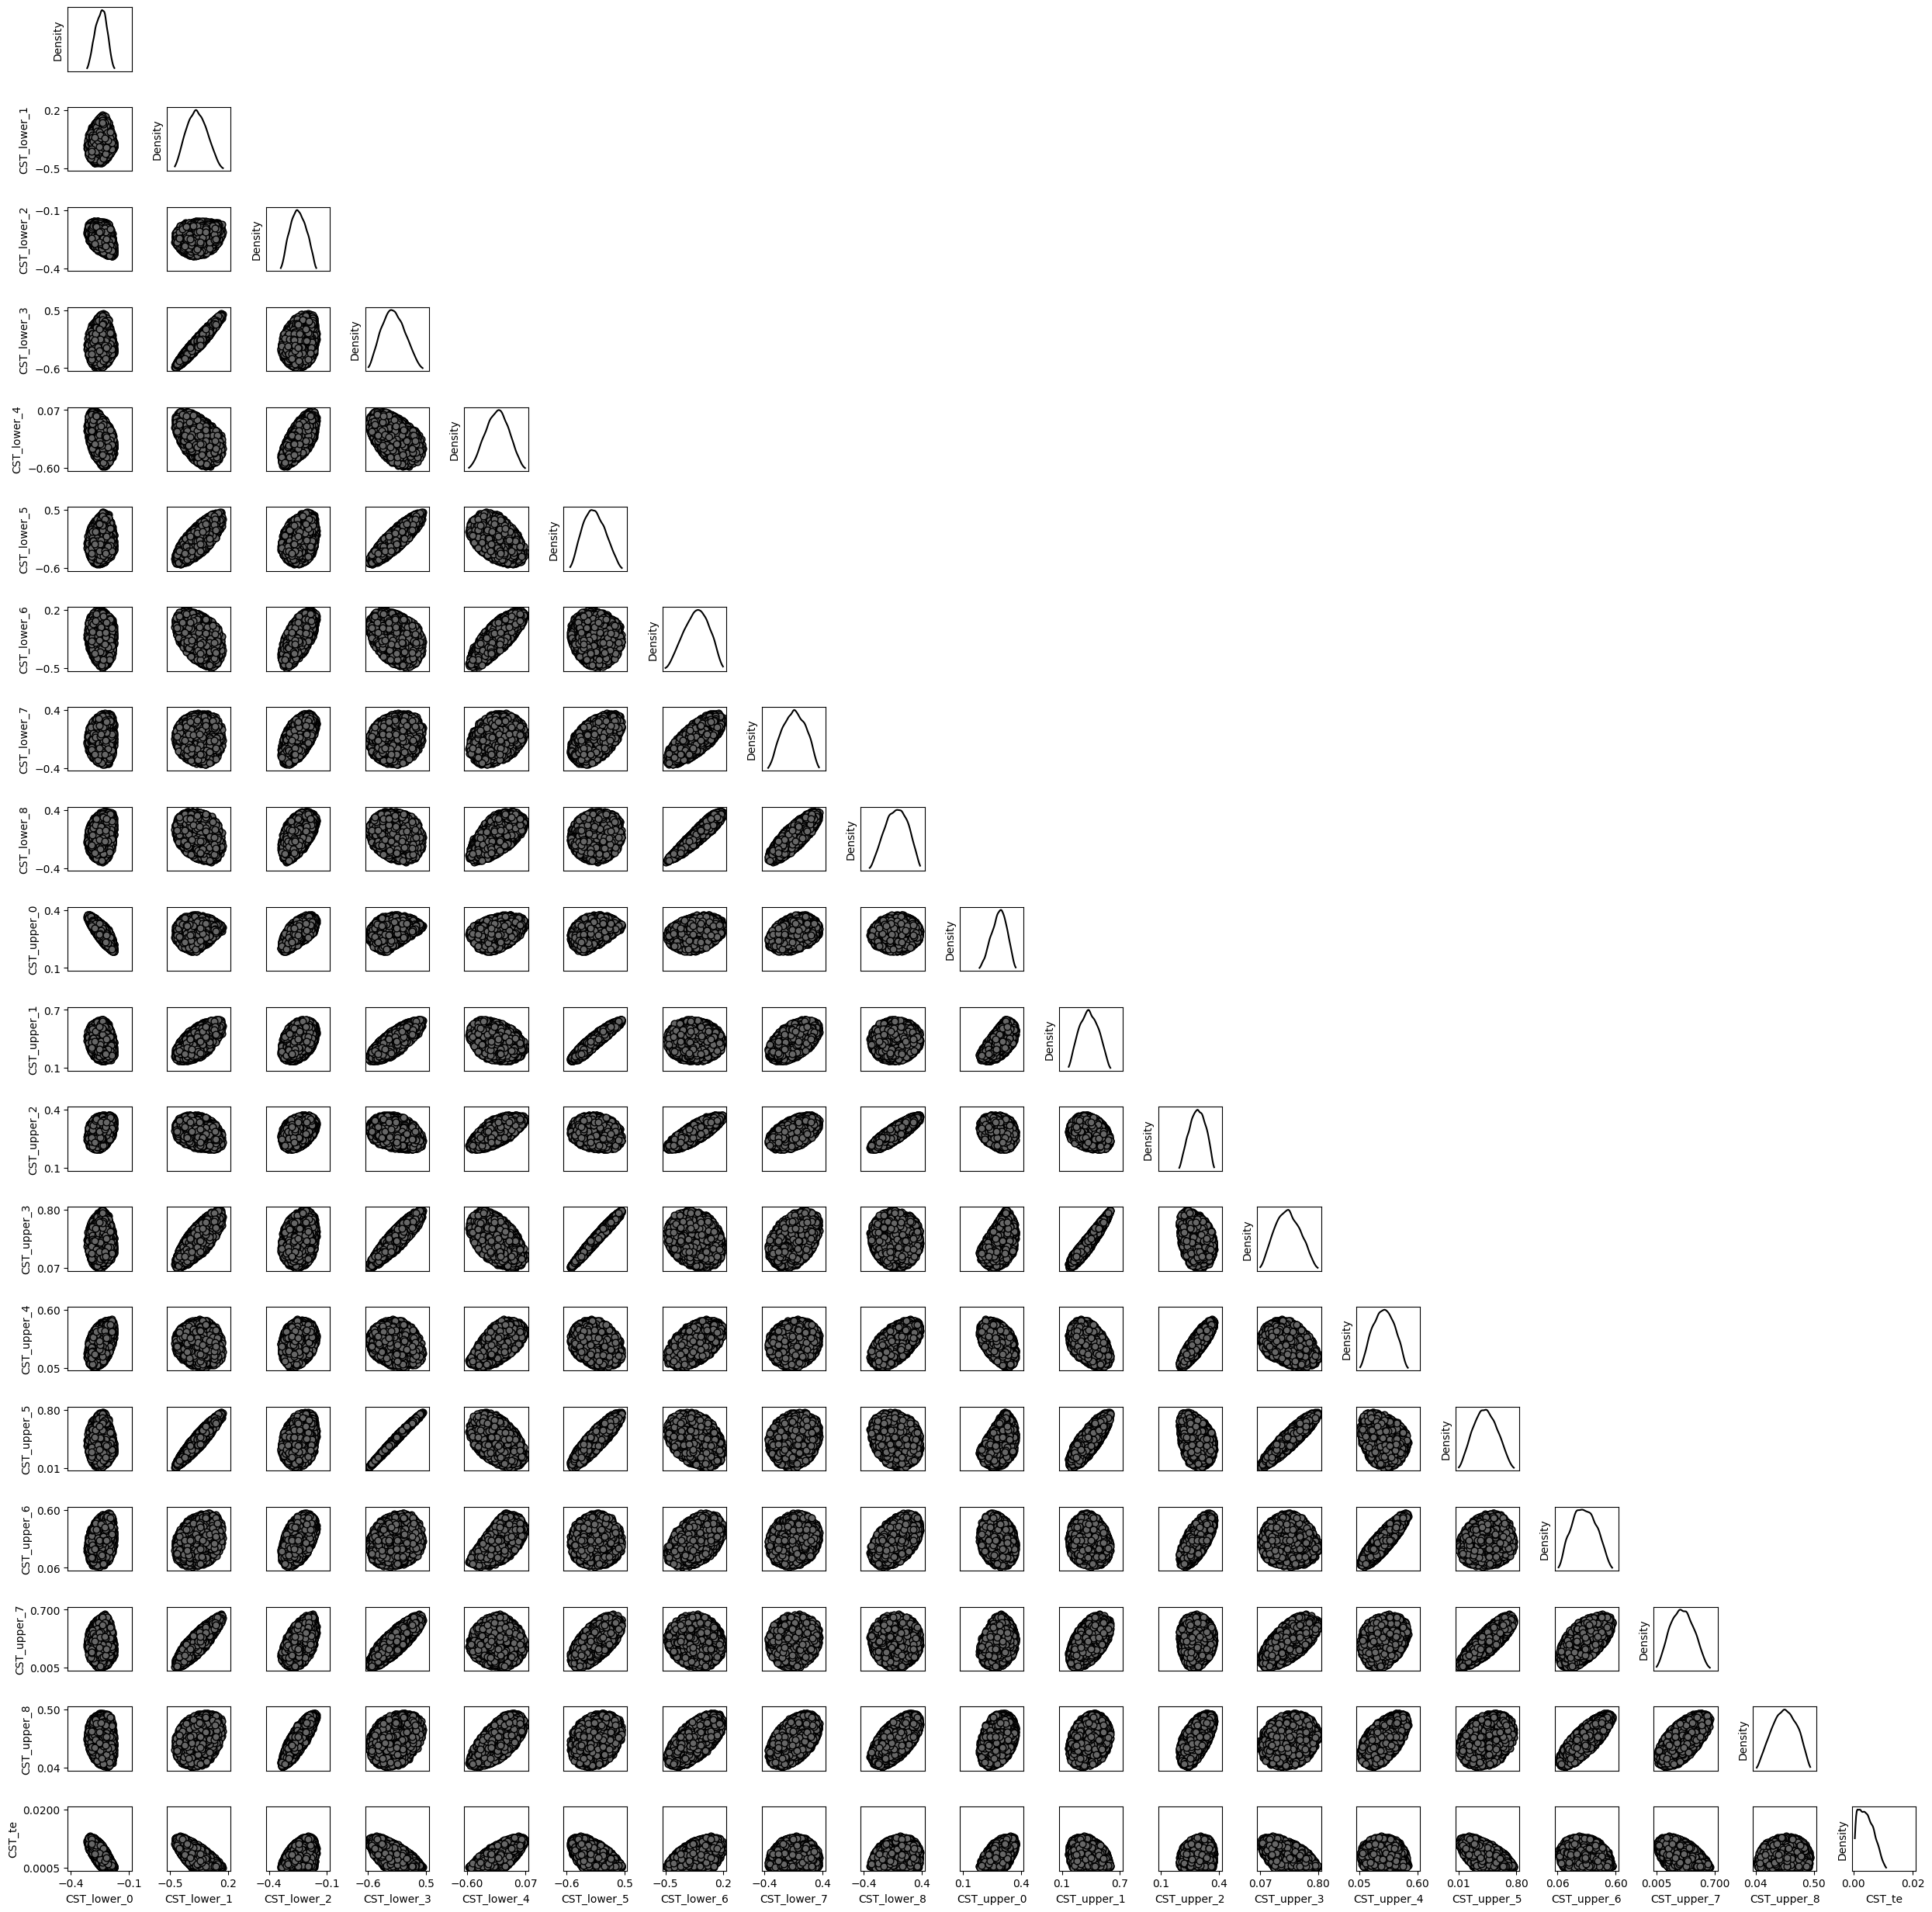

In [ ]:
with h5py.File(data_path, 'r') as hf:
    cst = da.from_array(hf['shape']['cst'], chunks=500).compute()

## Visualize distributions of CST parameters
m = cst.shape[1]
cst_limits = []
for i in range(m):
    lower = cst[:,i].min()
    upper = cst[:,i].max()
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    cst_limits.append([lower,upper])

cst_labels = ['CST_lower_{}'.format(i) for i in range(int((m-1)/2))]
cst_labels.extend(['CST_upper_{}'.format(i) for i in range(int((m-1)/2))])
cst_labels.extend(['CST_te'])

plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst[:,i].min(), cst[:,i].max())
            kde = gaussian_kde(cst[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
        else:
            plt.scatter(cst[:,j], cst[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]),
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


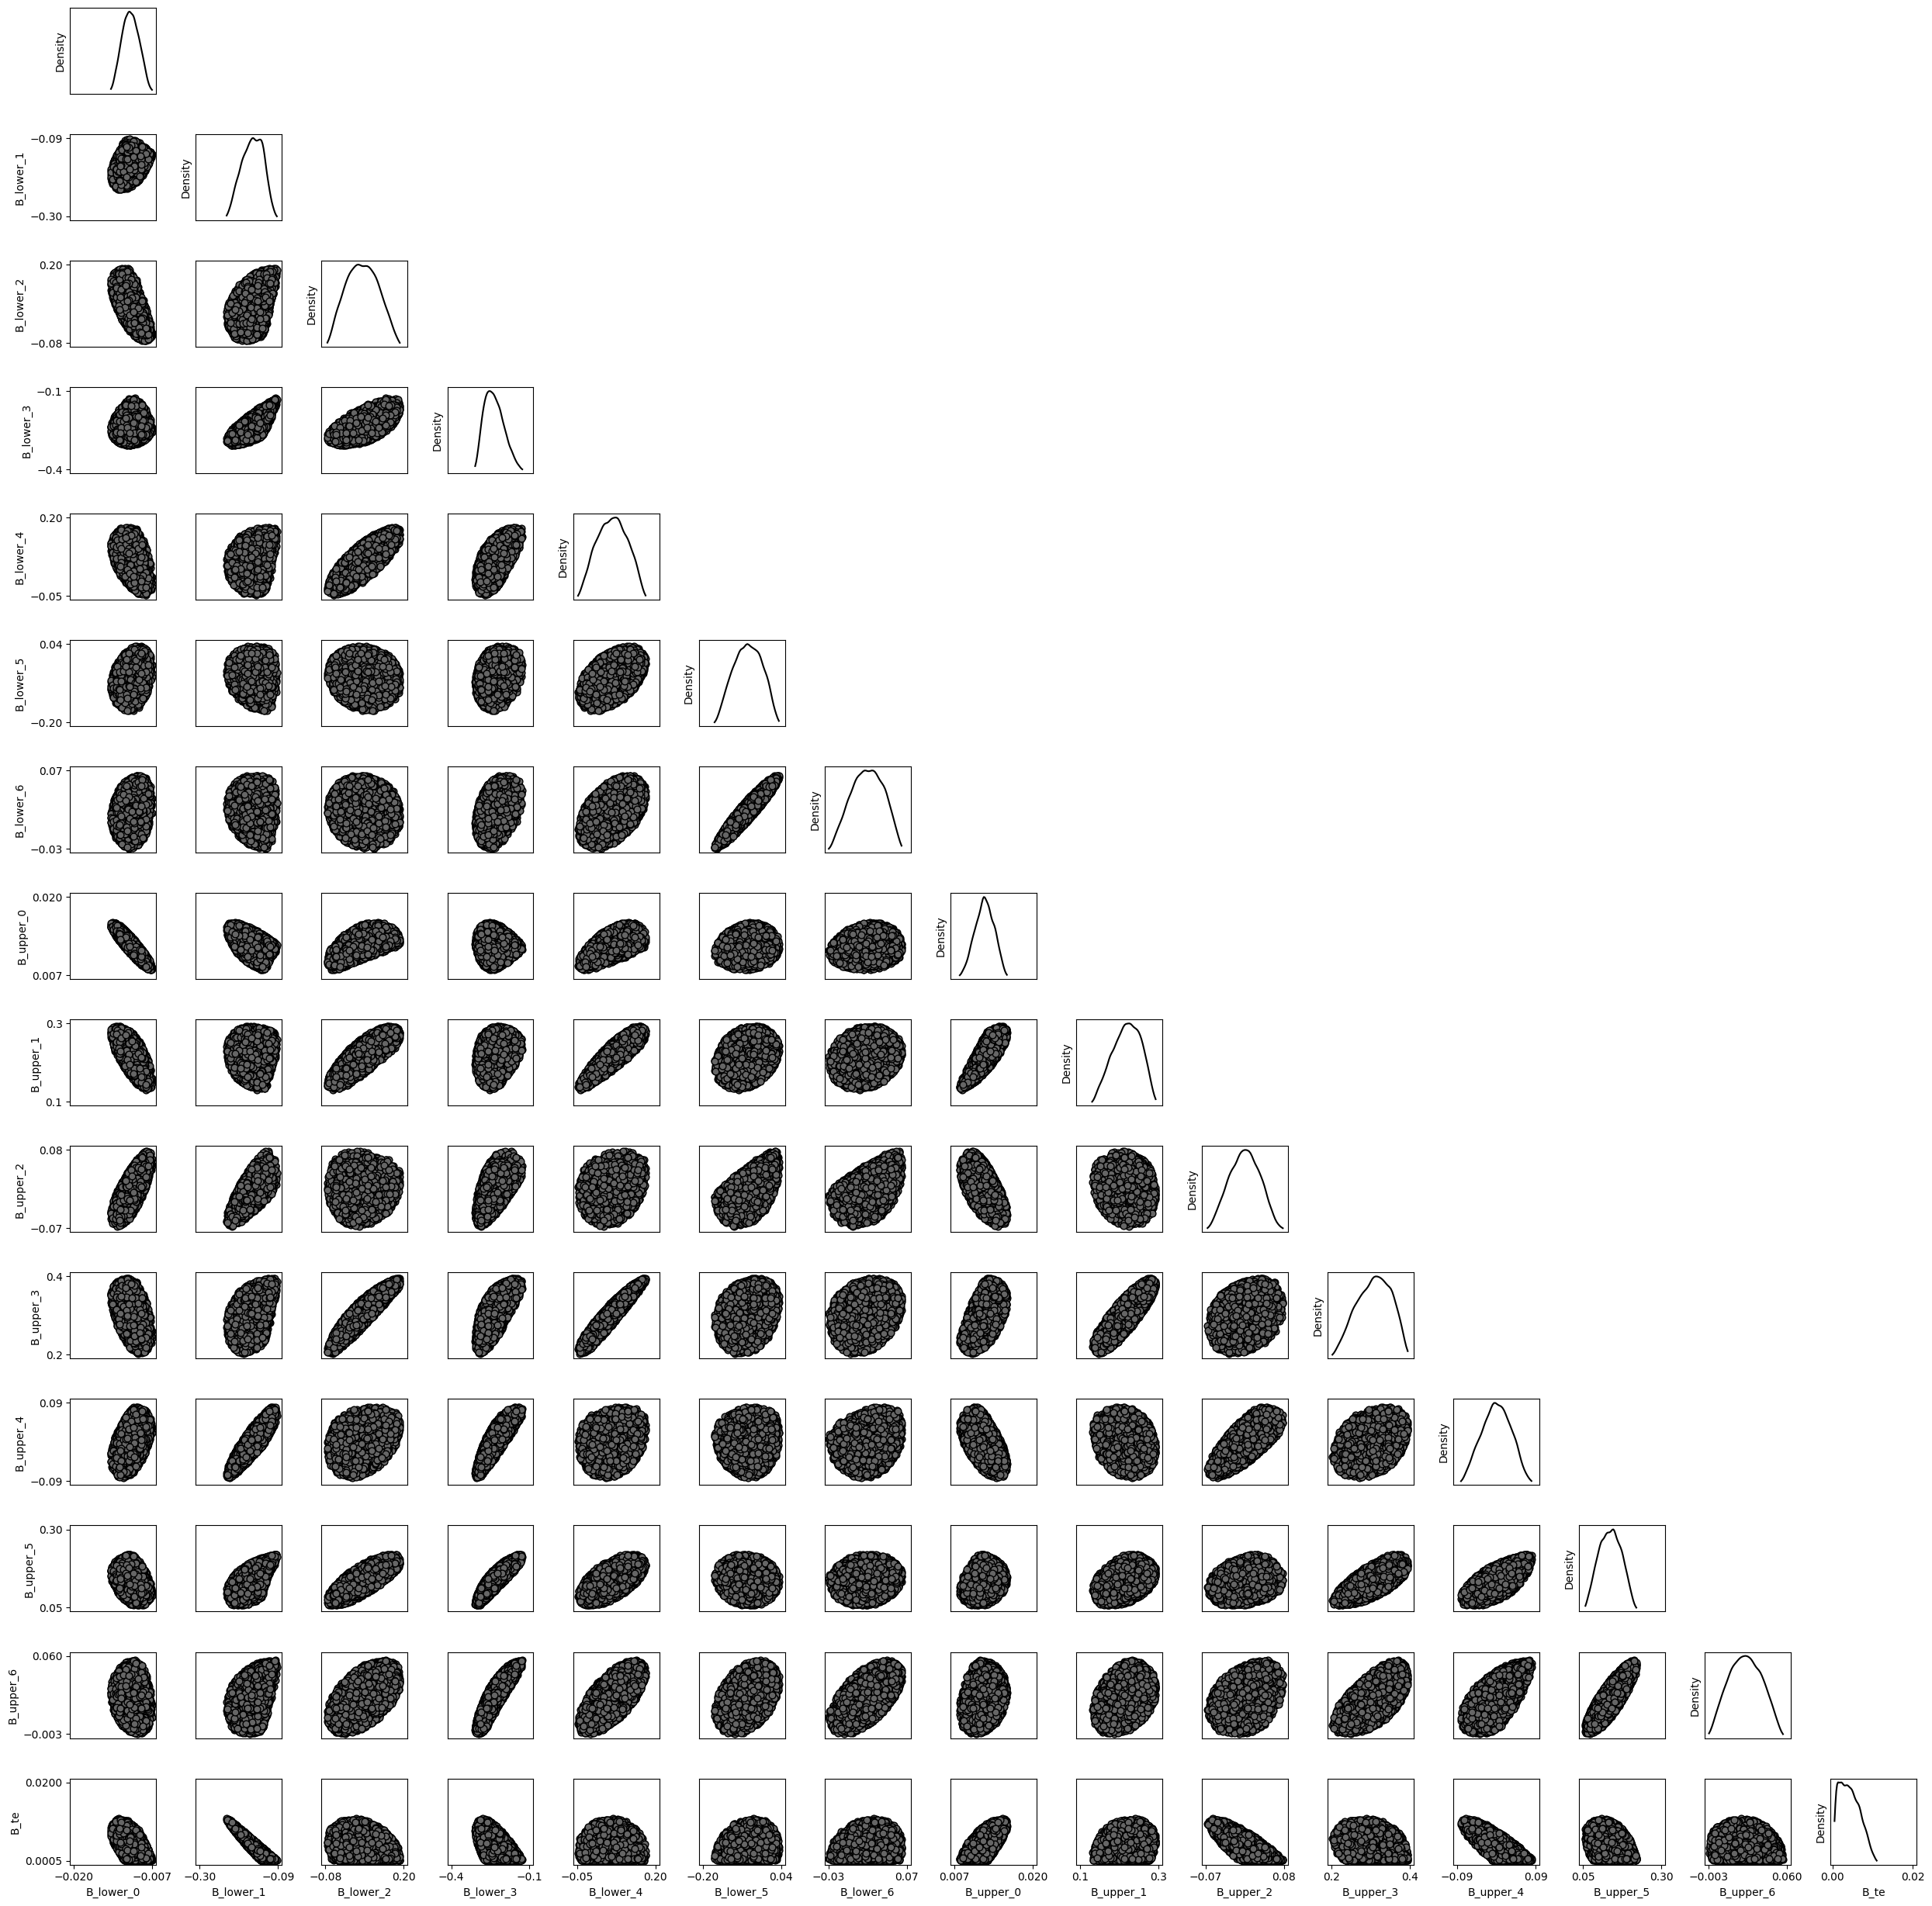

In [ ]:
with h5py.File(data_path, 'r') as hf:
    bezier = da.from_array(hf['shape']['bezier'], chunks=500).compute()

## Visualize distributions of Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier[:,i].min()
    upper = bezier[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_lower_{}'.format(i) for i in range(int((m-1)/2))]
bezier_labels.extend(['B_upper_{}'.format(i) for i in range(int((m-1)/2))])
bezier_labels.extend(['B_te'])

# Plot marginal distributions of the bezier data
plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier[:,i].min(), bezier[:,i].max())
            kde = gaussian_kde(bezier[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier[:,j], bezier[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Airfoil Shape and Aerodynamic Properties

In [ ]:
# # Parse the landmark datasets and extract thickness along the chord and camber line
# with h5py.File(data_path, 'r') as hf:    
#     landmarks = hf['shape']['landmarks'][()]
#     N_airfoils = landmarks.shape[0]
with h5py.File(data_path, 'r') as hf:
    landmarks = da.from_array(hf['shape']['landmarks'], chunks=500).compute()
    N_airfoils = landmarks.shape[0]

    
    # Calculate thickness at each x_c step except for the leading edge (x_c~0.0, index 500, axis=1)
    thickness_arr_2d = abs(landmarks[:,501:,1] - np.flip(landmarks[:,:500,1],axis=1))
    
    # Calculate camber / midpoint at each x_c step
    camber_arr_2d = (landmarks[:,501:,1] + np.flip(landmarks[:,:500,1],axis=1))/2
    
    # Create numpy array to represent x_c values at each thickness/camber step (0.002 increments between 0.002 and 1.0 inclusive)
    x_c_arr = np.resize(np.arange(0.002,1.002,0.002), thickness_arr_2d.shape[0]*500)

    # Reshape thickness array such that each row is one thickness value totaling 8996 airfoils * 500 landmarks per foil, output shape = (4498500,1)
    thickness_arr_1d = np.reshape(thickness_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in 0th column --> output shape = (4498500,2) 
    thickness_arr_1d = np.insert(thickness_arr_1d, 0, x_c_arr, axis=1)

    # Reshape camber array such that each row is one camber value totaling 8996 airfoils * 500 landmarks per foil (4498500,1)
    camber_arr_1d = np.reshape(camber_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in first 0th column --> (4498500,2) output
    camber_arr_1d = np.insert(camber_arr_1d, 0, x_c_arr, axis=1)


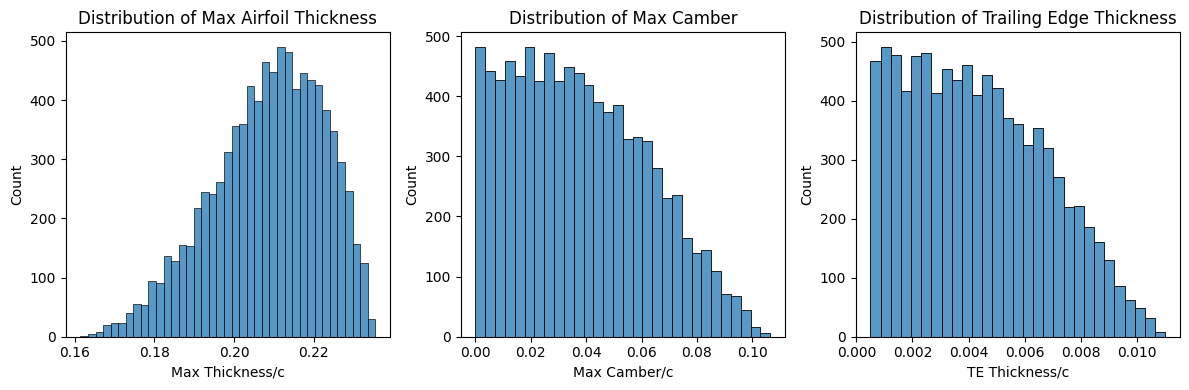

In [ ]:
# Visualize distribution of maximum thickness/maximum camber/trailing edge thickness across airfoils
plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.histplot(data=np.max(thickness_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Airfoil Thickness')
ax.set(xlabel='Max Thickness/c')

plt.subplot(132)
ax = sns.histplot(data=np.max(camber_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Camber')
ax.set(xlabel='Max Camber/c')

plt.subplot(133)
ax = sns.histplot(data=thickness_arr_2d[:,499], stat='count')
ax.set_title('Distribution of Trailing Edge Thickness')
ax.set(xlabel='TE Thickness/c')

plt.tight_layout()
plt.show()

In [28]:
# # Visualize average thickness along the chord and standard deviation across all airfoils
# plt.figure(figsize=(12, 4))

# plt.subplot(121)
# ax = sns.lineplot(data=thickness_arr_1d, x=thickness_arr_1d[:,0], y=thickness_arr_1d[:,1], 
#                   errorbar='sd', n_boot=(len(thickness_arr_1d)))
# ax.set(xlabel='x/c', ylabel='thickness/c')
# ax.set_title('Avg Airfoil Thickness along the Chord')

# plt.subplot(122)
# ax = sns.lineplot(data=camber_arr_1d, x=camber_arr_1d[:,0], y=camber_arr_1d[:,1], 
#                   errorbar='sd', n_boot=(len(camber_arr_1d)))
# ax.set(xlabel='x/c', ylabel='camber/c')
# ax.set_title('Avg Camber Line along the Chord')
# ax.set_ylim(ymin=-0.025, ymax=0.10)

# plt.tight_layout()
# plt.show()

import pandas as pd

thickness_df = pd.DataFrame(thickness_arr_1d, columns=['x', 'thickness'])
camber_df = pd.DataFrame(camber_arr_1d, columns=['x', 'camber'])

plt.figure(figsize=(12, 4))

plt.subplot(121)
ax = sns.lineplot(data=thickness_df, x='x', y='thickness', errorbar='sd', n_boot=len(thickness_df))
ax.set(xlabel='x/c', ylabel='thickness/c')
ax.set_title('Avg Airfoil Thickness along the Chord')

plt.subplot(122)
ax = sns.lineplot(data=camber_df, x='x', y='camber', errorbar='sd', n_boot=len(camber_df))
ax.set(xlabel='x/c', ylabel='camber/c')
ax.set_title('Avg Camber Line along the Chord')
ax.set_ylim(ymin=-0.025, ymax=0.10)

plt.tight_layout()
plt.show()


NameError: name 'thickness_arr_1d' is not defined

C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])
C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])
C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])


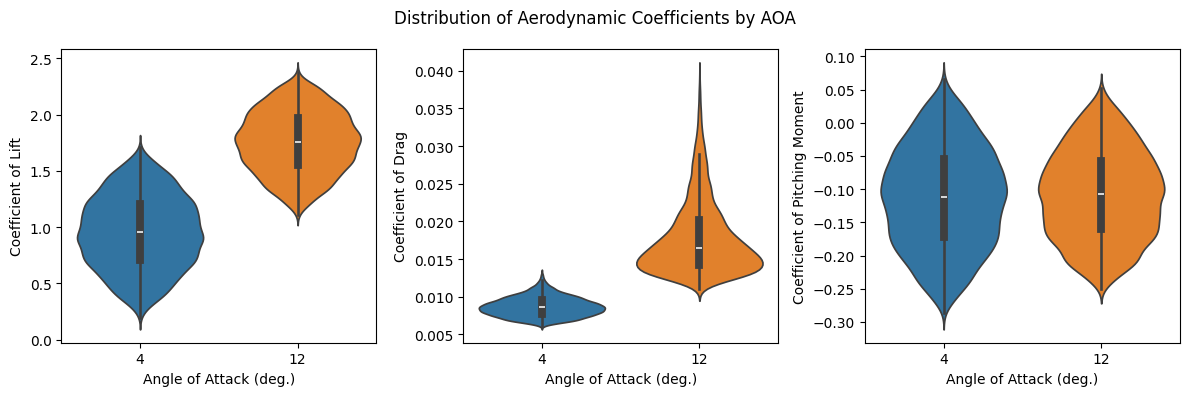

In [ ]:
# Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
with h5py.File(data_path, 'r') as hf:
    cl_alpha04 = da.from_array(hf['alpha+04']['C_l'], chunks=500).compute()
    cd_alpha04 = da.from_array(hf['alpha+04']['C_d'], chunks=500).compute()
    cm_alpha04 = da.from_array(hf['alpha+04']['C_m'], chunks=500).compute()

    cl_alpha12 = da.from_array(hf['alpha+12']['C_l'], chunks=500).compute()
    cd_alpha12 = da.from_array(hf['alpha+12']['C_d'], chunks=500).compute()
    cm_alpha12 = da.from_array(hf['alpha+12']['C_m'], chunks=500).compute()

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.violinplot(data=[cl_alpha04, cl_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = sns.violinplot(data=[cd_alpha04, cd_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = sns.violinplot(data=[cm_alpha04, cm_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Distribution of Aerodynamic Coefficients by AOA')
plt.tight_layout()
plt.show()

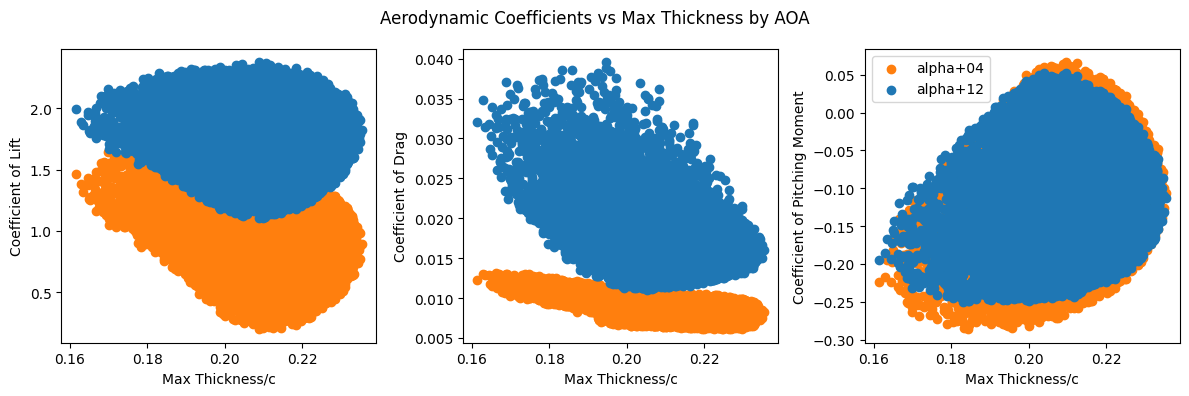

In [ ]:
# # Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
# with h5py.File(data_path, 'r') as hf:
#         cl_alpha04 = hf['alpha+04']['C_l'][()]
#         cd_alpha04 = hf['alpha+04']['C_d'][()]
#         cm_alpha04 = hf['alpha+04']['C_m'][()]
        
#         cl_alpha12 = hf['alpha+12']['C_l'][()]
#         cd_alpha12 = hf['alpha+12']['C_d'][()]
#         cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.legend(loc='upper left')
plt.suptitle('Aerodynamic Coefficients vs Max Thickness by AOA')
plt.tight_layout()
plt.show()

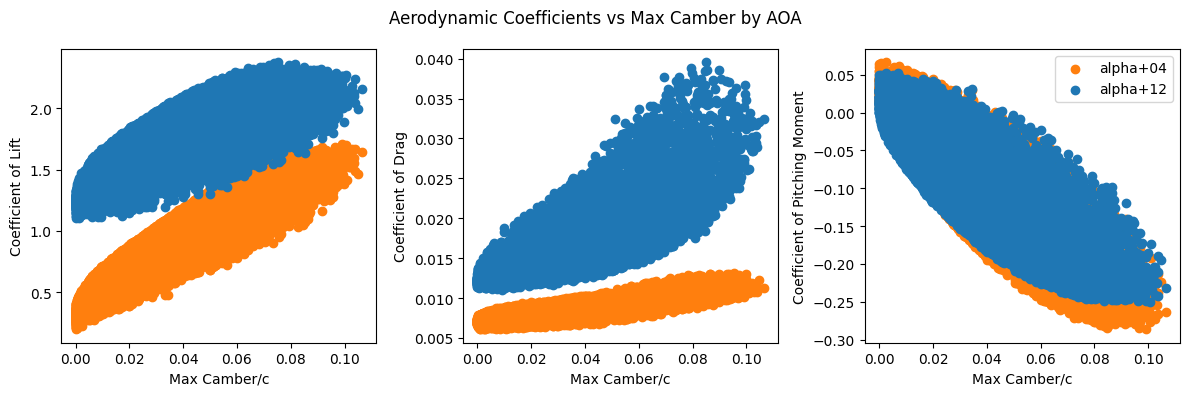

In [ ]:
# # Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
# with h5py.File(data_path, 'r') as hf:
#         cl_alpha04 = hf['alpha+04']['C_l'][()]
#         cd_alpha04 = hf['alpha+04']['C_d'][()]
#         cm_alpha04 = hf['alpha+04']['C_m'][()]
        
#         cl_alpha12 = hf['alpha+12']['C_l'][()]
#         cd_alpha12 = hf['alpha+12']['C_d'][()]
#         cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Aerodynamic Coefficients vs Max Camber by AOA')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Dimension Reduction of Parameterizations

--------------------------------------------------
Number of Components = 1
Explained Variance:
[7.2918174]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[7.2918174  6.36463173]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[7.2918174  6.36463173 3.42187149]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761 0.05012966]


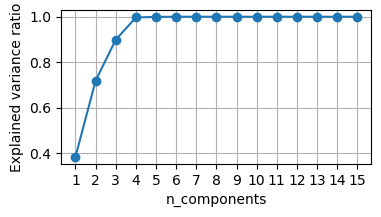

In [ ]:
## Explore the PCA space of the cst data
# Aim to reduce cst data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
cst_std = std_scaler.fit_transform(cst)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(cst_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

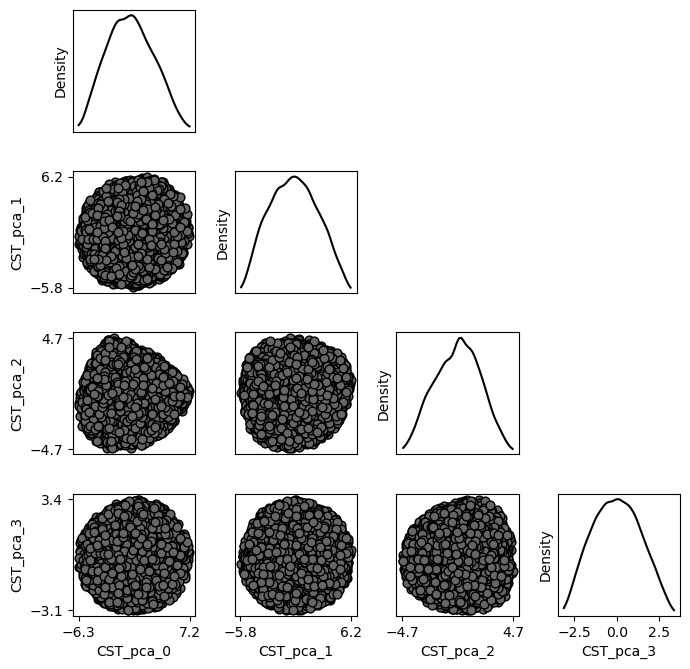

In [ ]:
# Transform standardized cst data to (8996, 4) via PCA
pca = PCA(n_components=4)
cst_pca = pca.fit_transform(cst_std)

## Visualize distributions of CST parameters
# Capture number of parameters in CST representation
m = cst_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
cst_limits = []
for i in range(m):
    # Capture min and max values in each CST parameter across all airfoils
    lower = cst_pca[:,i].min()
    upper = cst_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    cst_limits.append([lower,upper])

# Create labels for CST parameters
cst_labels = ['CST_pca_{}'.format(i) for i in range(int((m)))]


# Plot marginal distributions of the CST data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst_pca[:,i].min(), cst_pca[:,i].max())
            kde = gaussian_kde(cst_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(cst_pca[:,j], cst_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]), 
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]), 
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


--------------------------------------------------
Number of Components = 1
Explained Variance:
[6.65828063]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[6.65828063 4.71747706]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[6.65828063 4.71747706 2.54334009]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004 0.02648279]


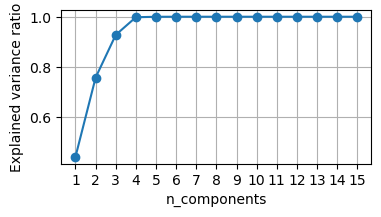

In [ ]:
## Explore the PCA space of the bezier data
# Aim to reduce bezier data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
bezier_std = std_scaler.fit_transform(bezier)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(bezier_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

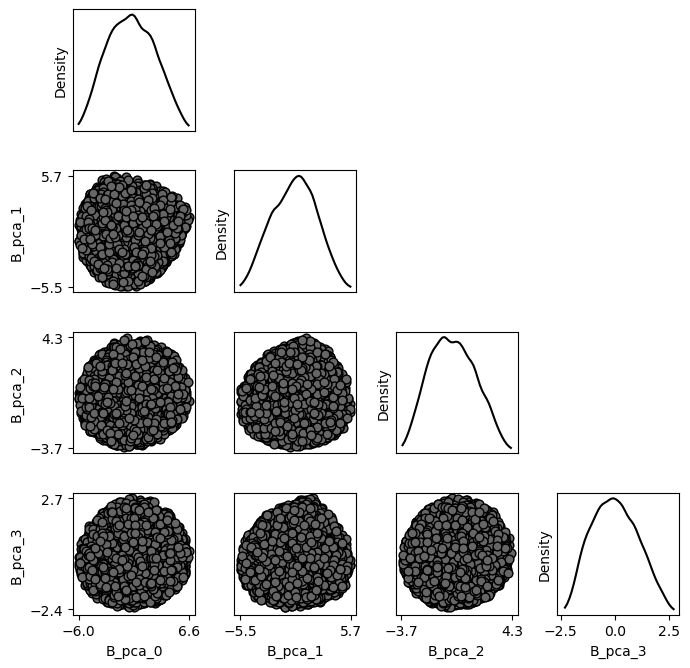

In [ ]:
# Transform standardized bezier data to (8996, 4) via PCA
pca = PCA(n_components=4)
bezier_pca = pca.fit_transform(bezier_std)


## Visualize distributions of PCA Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier_pca[:,i].min()
    upper = bezier_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_pca_{}'.format(i) for i in range(int((m)))]

# Plot marginal distributions of the bezier data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier_pca[:,i].min(), bezier_pca[:,i].max())
            kde = gaussian_kde(bezier_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier_pca[:,j], bezier_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Examine Flow Field Data

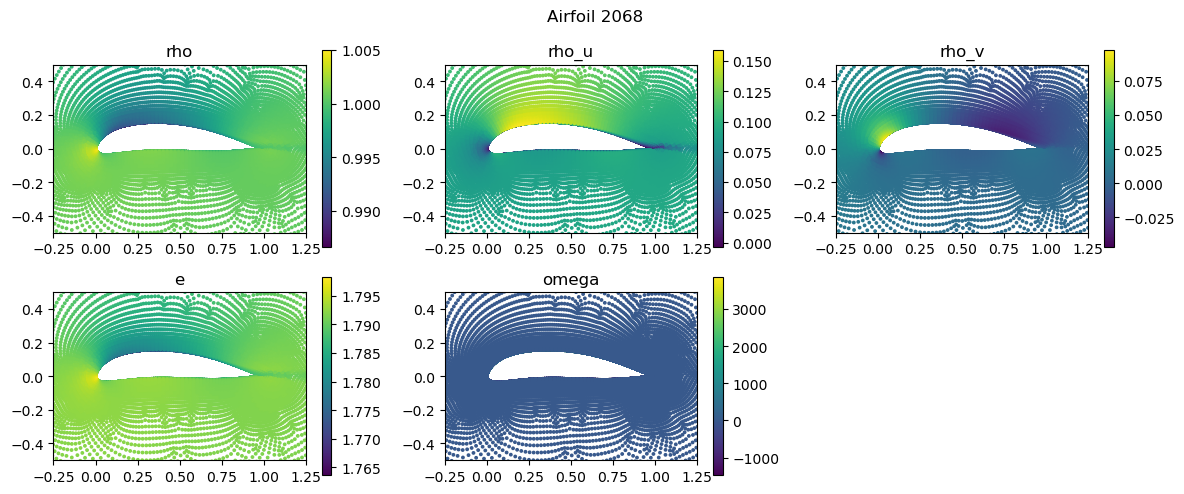

In [ ]:
# Plot flow field data for randomly selected airfoils

val_list = ['rho', 'rho_u', 'rho_v', 'e', 'omega']

with h5py.File(data_path, 'r') as hf:
    idx = np.random.randint(hf['shape']['landmarks'].shape[0])
    
    x = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['x'][()]
    y = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['y'][()]
        
    plt.figure(figsize=(12, 5))
    for i, v in enumerate(val_list):
        val = hf['alpha+04']['flow_field']['{:04d}'.format(idx)][v][()]
        
        tf = (x >= -0.25) & (x <= 1.25) & (y >= -0.5) & (y <= 0.5)
        vmin, vmax = np.min(val[tf]), np.max(val[tf])
    
        plt.subplot(2, 3, i+1)
        plt.scatter(x, y, c=val, vmin=vmin, vmax=vmax, s=3)
        plt.xlim(-0.25, 1.25)
        plt.ylim(-0.5, 0.5)
        plt.colorbar()
        plt.title(v)
        plt.gca().set_aspect(1.)

    plt.suptitle('Airfoil {:04d}'.format(idx))
    plt.tight_layout()
    plt.show()